# Notebook for Making Figures for Frame 5.

## Prepare the notebook.

### Import Libraries.

In [1]:
import math
import os
import sys
import yaml

import hydra
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model, generate_with_condition, generated_density_knn, get_adata_from_idx


### Define Color Palette for Cell Types.

In [2]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'late_MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

### Read Annotation Configurations.

In [3]:
config_path = "../../../inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config_path, "r") as fb:
    annot_dict = yaml.safe_load(fb)
protocol_cols = annot_dict["protocol_columns"]

### Read Constraints File.

In [4]:
constraints_config_path = "../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]


### Load Configurations.

In [5]:
with os.environ["REPO_ROOT"] = os.path.abspath("../../..")

hydra.initialize(
    config_path="../../../inverse/loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )

/tmp/ipykernel_3076356/10581362.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


## Load Data.

### Load Annotated Data without LPHO012 Experiment.

In [6]:
path_adata_old = "../../../project_folder/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_old_experiments_.h5ad"
adata_old = sc.read_h5ad(path_adata_old)
adata_old

AnnData object with n_obs × n_vars = 449218 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Annotated Data with LPHO012 Experiment.

In [7]:
path_adata_new = "../../../project_folder/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
adata_new = sc.read_h5ad(path_adata_new)
adata_new.uns["cell_type_colors"] = color_map
adata_new

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Full Adata without LPHO012.

In [8]:
path_adata_full_old = "../../../project_folder/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad"
adata_full_old = sc.read_h5ad(path_adata_full_old)
adata_full_old

AnnData object with n_obs × n_vars = 48189887 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Load Full Adata with LPHO012.

In [9]:
path_adata_full = "../../../project_folder/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad"
adata_full = sc.read_h5ad(path_adata_full)
adata_full

AnnData object with n_obs × n_vars = 52085765 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Prepare Unique Real Conditions.

In [10]:
# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_conds = adata_full.obs[protocol_cols].astype(float).values   # or use obs[protocol_columns].values
exp_nums = adata_full.obs["experiment_number"].values

# Get unique condition per experiment
unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]   # all cells in same exp share the same condition
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
exp_labels = np.array(exp_labels)


## Panel A: UMAP Plot of Old Data, Highlighting MgkPro cells.

Updated color for late_MgkPro to #3a4f6a


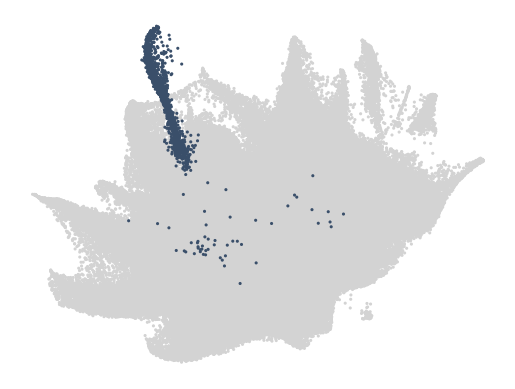

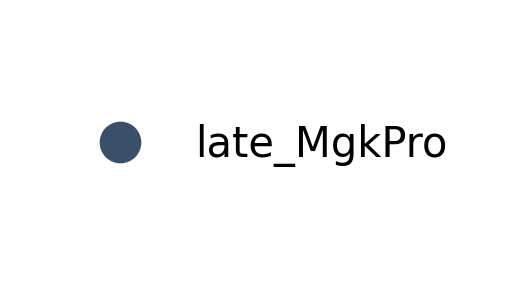

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc

# ----------------------------------------------------------------------
# 1. Ensure the color for 'late_MgkPro' is correctly set
# ----------------------------------------------------------------------
if not isinstance(adata_old.uns.get('cell_type_colors'), list):
    categories = adata_old.obs['cell_type'].cat.categories
    old_colors = adata_old.uns.get('cell_type_colors', {})
    adata_old.uns['cell_type_colors'] = [
        old_colors.get(ct, '#cccccc') if isinstance(old_colors, dict) else '#cccccc'
        for ct in categories
    ]

cell_type_colors = adata_old.uns['cell_type_colors']
categories = adata_old.obs['cell_type'].cat.categories.tolist()

target_cell = 'late_MgkPro'
if target_cell in categories:
    idx = categories.index(target_cell)
    cell_type_colors[idx] = '#3a4f6a'
    print(f"Updated color for {target_cell} to #3a4f6a")
else:
    print(f"'{target_cell}' not found in categories. Available: {categories}")

# ----------------------------------------------------------------------
# 2. Plot UMAP with only the dots (no legend, no axes, no labels)
# ----------------------------------------------------------------------
ax = sc.pl.umap(
    adata_old,
    color="cell_type",
    s=20,
    groups=["late_MgkPro"],
    show=False,
    frameon=False,          # remove the frame box
    legend_loc='none',      # remove legend
    title=''                # remove title
)

# If the return is a list of Axes (for multiple panels), take the first one
if isinstance(ax, list):
    ax = ax[0]

# Remove all ticks and tick labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

# Set axis labels to empty strings (explicitly)
ax.set_xlabel('')
ax.set_ylabel('')

# Remove the four spines (though frameon=False already removes them, this is safe)
for spine in ax.spines.values():
    spine.set_visible(False)

# Save high-quality figure (only dots)
plt.savefig(
    '../plots/umap_late_MgkPro_old_data.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------------------------------------------------
# Save the legend separately (with a DOT / circle marker)
# ----------------------------------------------------------------------
legend_handle = Line2D([0], [0], marker='o', color='none', 
                       markerfacecolor='#3a4f6a', markersize=10,
                       markeredgecolor='none', label='late_MgkPro')

fig_legend = plt.figure(figsize=(2, 1), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=[legend_handle], loc='center', frameon=False)
fig_legend.savefig('../plots/umap_legend_separate.png', bbox_inches='tight', dpi=300)
plt.show()


## Panel B: Frequency of Late MgkPro Across Conditions.

### Compute Proportions.

In [12]:
# get unique concentrations
unique_concs = np.unique(adata_old.obs[protocol_cols].astype(float).values, axis=0)
concs_df = pd.DataFrame(unique_concs, columns=protocol_cols)

# compute proportions
props = []
for idx, row in tqdm(concs_df.iterrows()):
    # slice adata for current experiment
    row_vals = row.values
    rmask = np.all(adata_old.obs[protocol_cols].astype(float).values == row_vals, axis=1)
    radata = adata_old[rmask]
    nexp = rmask.sum()

    # compute conts of MgkPro
    ct_mask = radata.obs.cell_type == "late_MgkPro"
    n_ct = ct_mask.sum()

    # proportion
    ct_prop = (n_ct / nexp).item()
    props.append(ct_prop)
concs_df["late_MgkPro_prop"] = props
concs_df["condition"] = np.arange(len(concs_df))

97it [00:02, 36.73it/s]


### Plot.

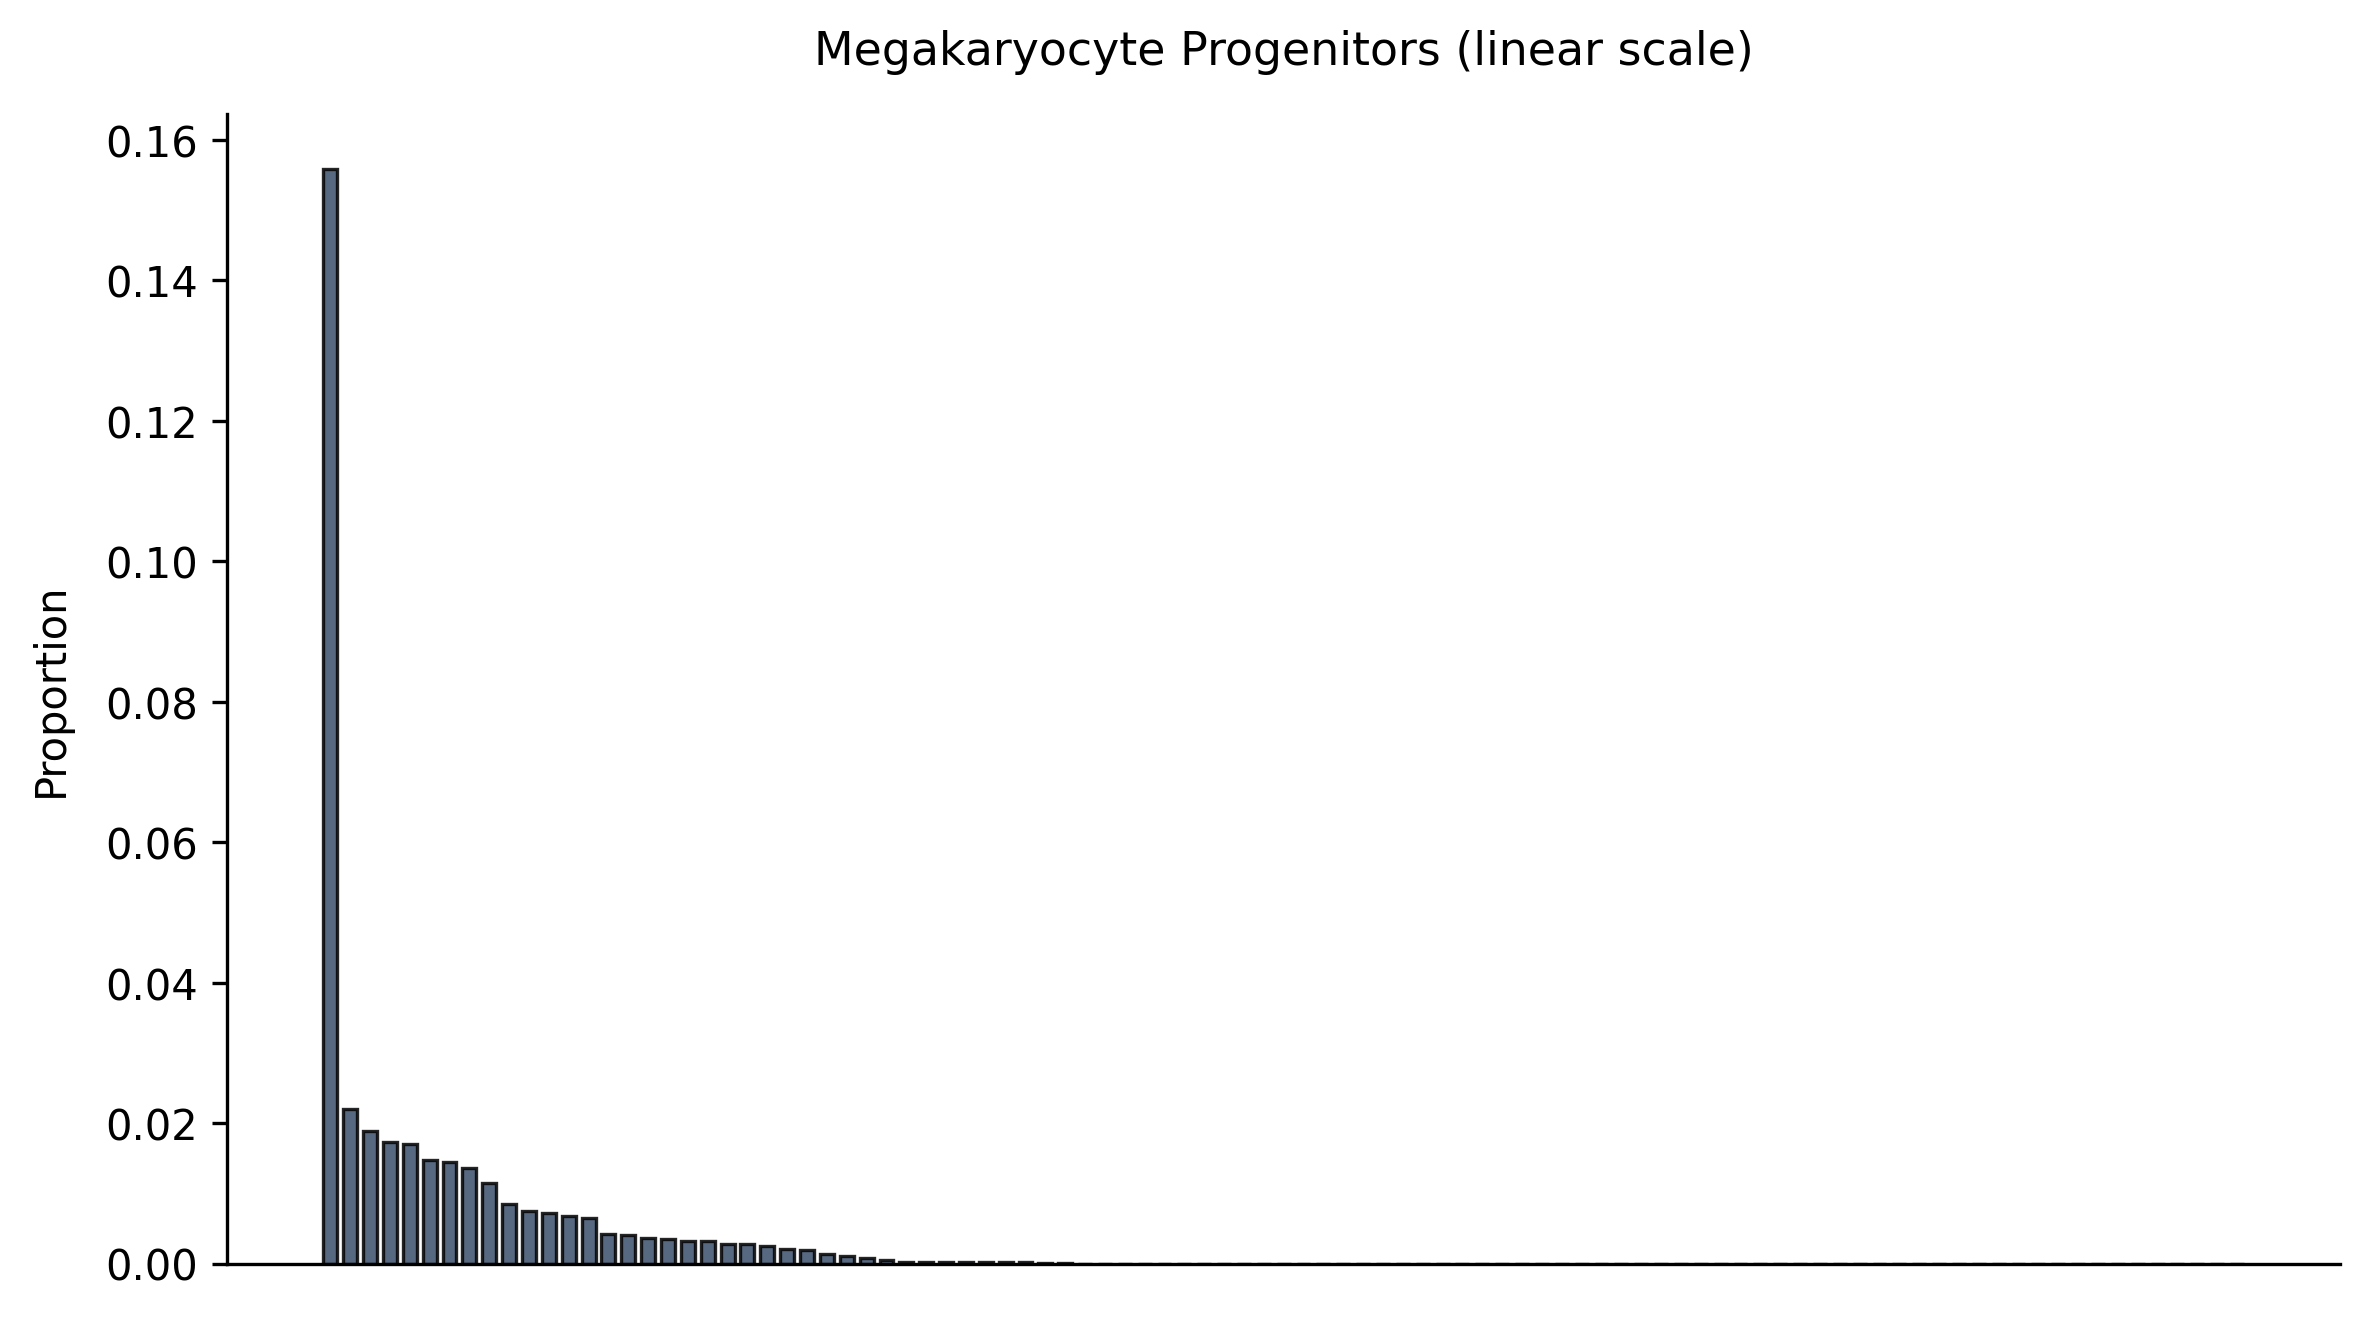

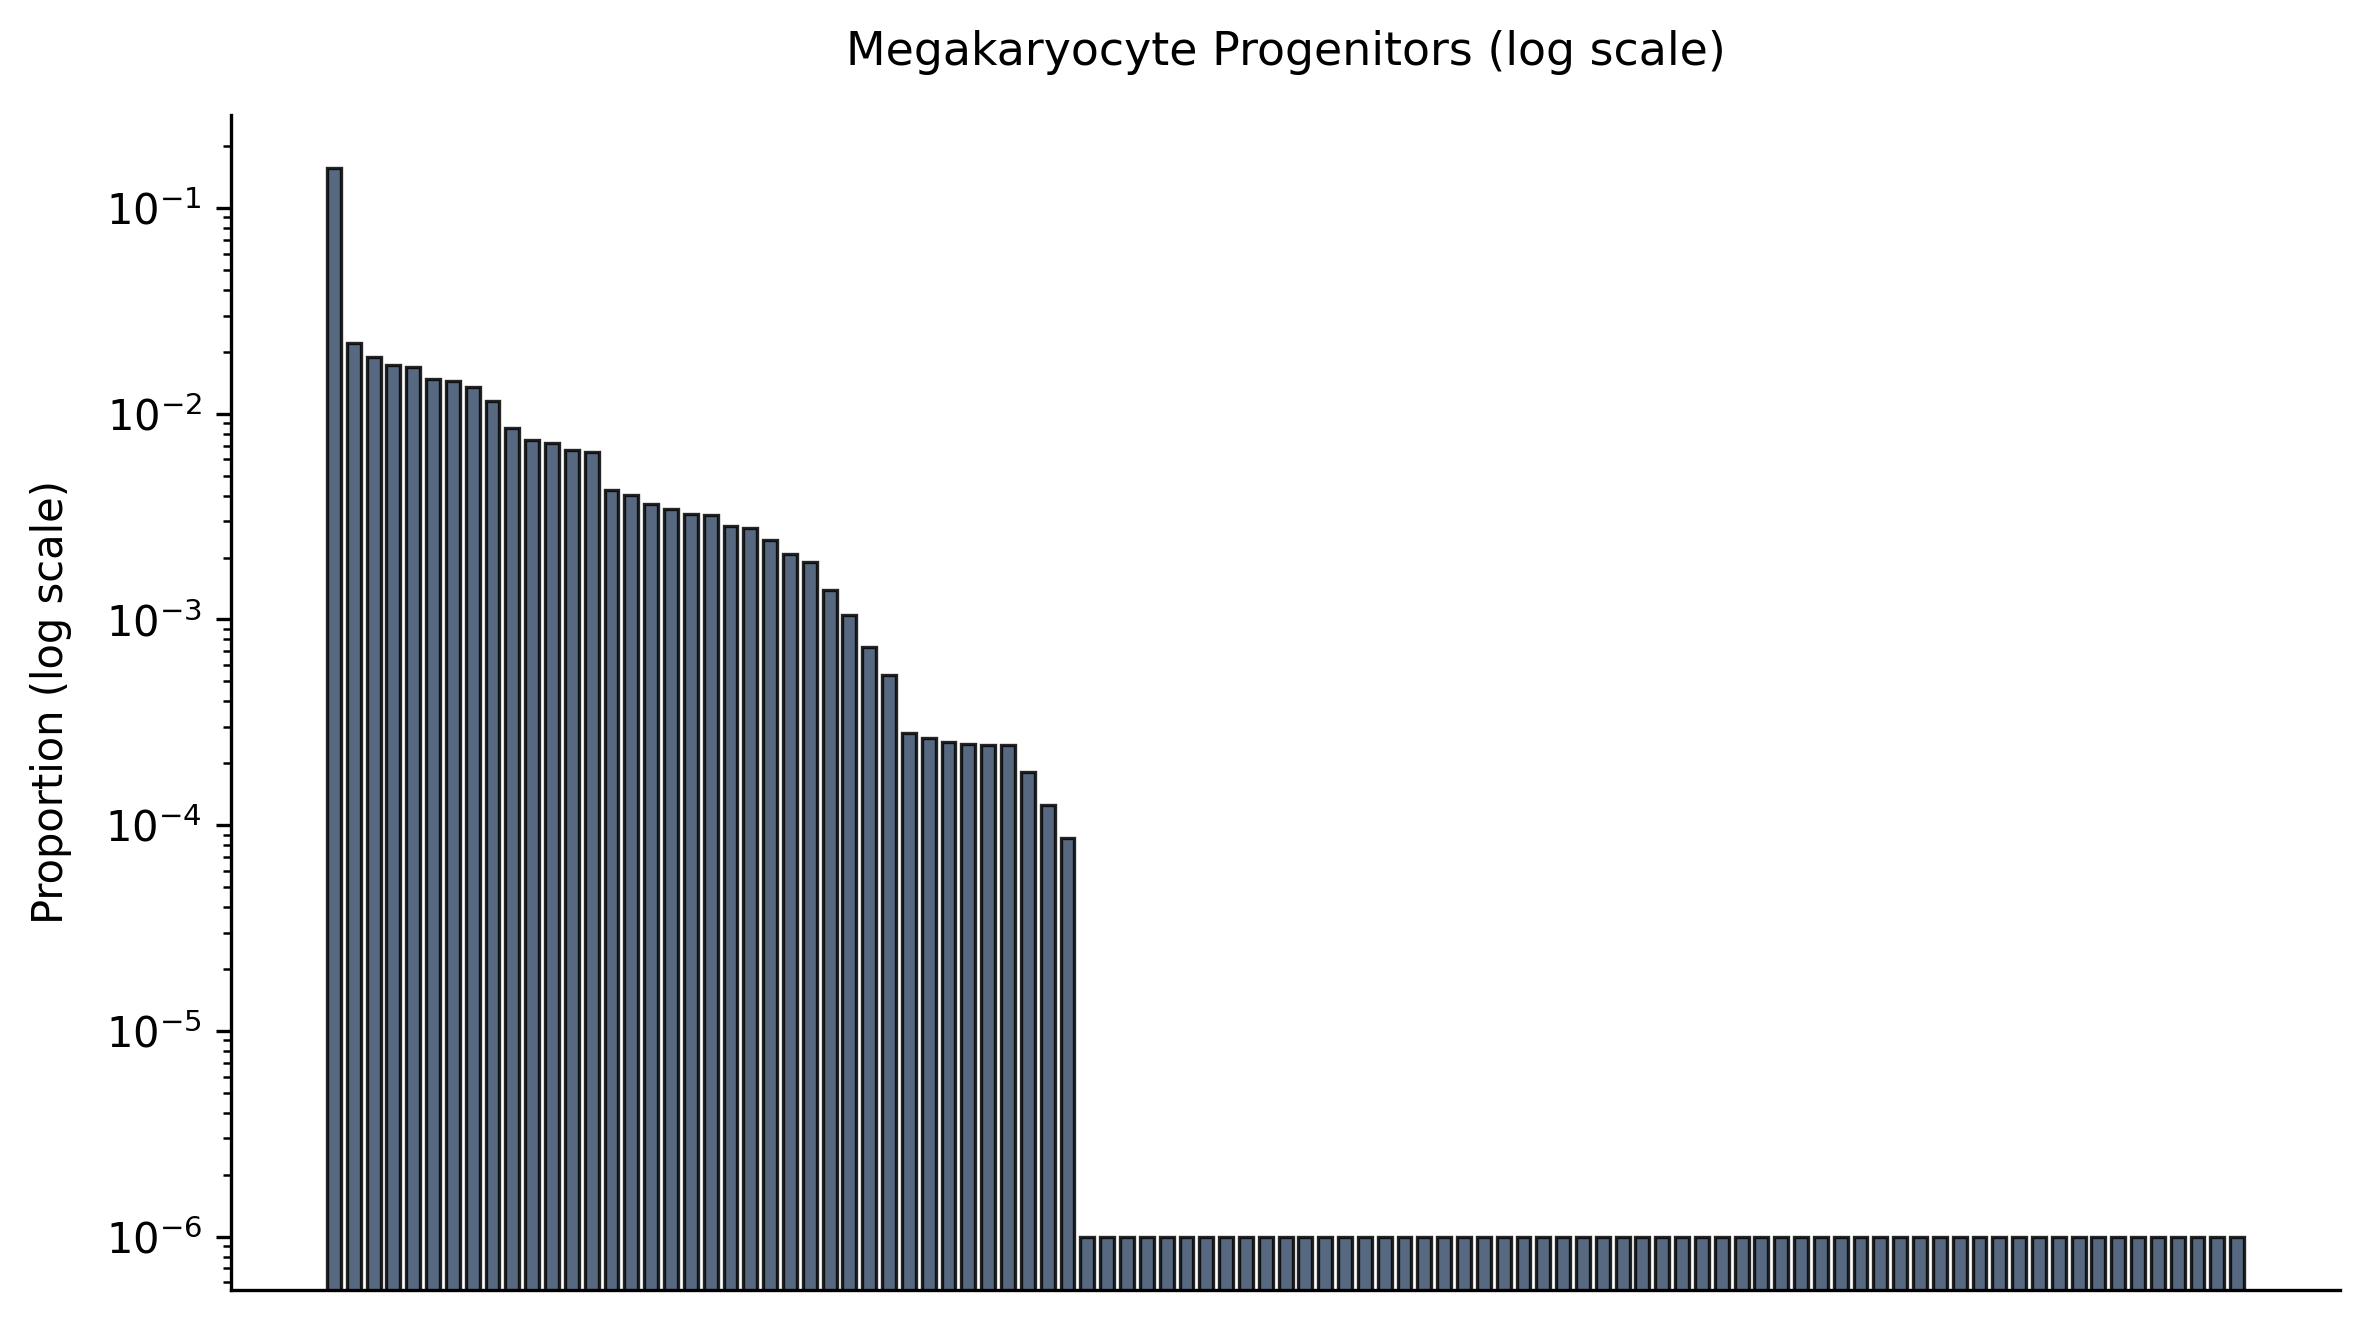

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your colour for late_MgkPro
color = color_map["late_MgkPro"]

# Prepare sorted data
concs_df_sorted = concs_df.sort_values('late_MgkPro_prop', ascending=False).reset_index(drop=True)
x_values = range(len(concs_df_sorted))

# ----------------------------------------------------------------------
# Figure 1: Linear scale (stylized)
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 4.5), dpi=300)

bars = plt.bar(x_values, concs_df_sorted['late_MgkPro_prop'],
               width=0.7,
               color=color,
               edgecolor='black',
               linewidth=0.8,
               alpha=0.85,
               zorder=2)

# Remove x‑ticks and labels
plt.xticks([])
plt.tick_params(axis='x', length=0)


# Labels and title
plt.ylabel('Proportion', fontsize=10, labelpad=8)
plt.title('Megakaryocyte Progenitors (linear scale)', fontsize=11, pad=12)

# Remove top/right spines
sns.despine()

# Optionally add value labels on top of bars (choose a few to avoid clutter)
# Uncomment if you want labels for all bars:
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
#              f'{height:.2f}', ha='center', va='bottom', fontsize=5)

plt.tight_layout()
plt.savefig('../plots/proportion_late_MgkPro_linear_old_data.png', bbox_inches='tight', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# Figure 2: Log scale (stylized, handling zeros)
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 4.5), dpi=300)

# Replace 0 with a small positive value for log plotting (1e-6)
y_log = concs_df_sorted['late_MgkPro_prop'].clip(lower=1e-6)

bars = plt.bar(x_values, y_log,
               width=0.7,
               color=color,
               edgecolor='black',
               linewidth=0.8,
               alpha=0.85,
               zorder=2)

plt.xticks([])
plt.tick_params(axis='x', length=0)
plt.yscale('log')

plt.ylabel('Proportion (log scale)', fontsize=10, labelpad=8)
plt.title('Megakaryocyte Progenitors (log scale)', fontsize=11, pad=12)

sns.despine()
plt.tight_layout()
plt.savefig('../plots/proportion_late_MgkPro_log_old_data.png', bbox_inches='tight', dpi=300)
plt.show()


### Boxplot Instead.

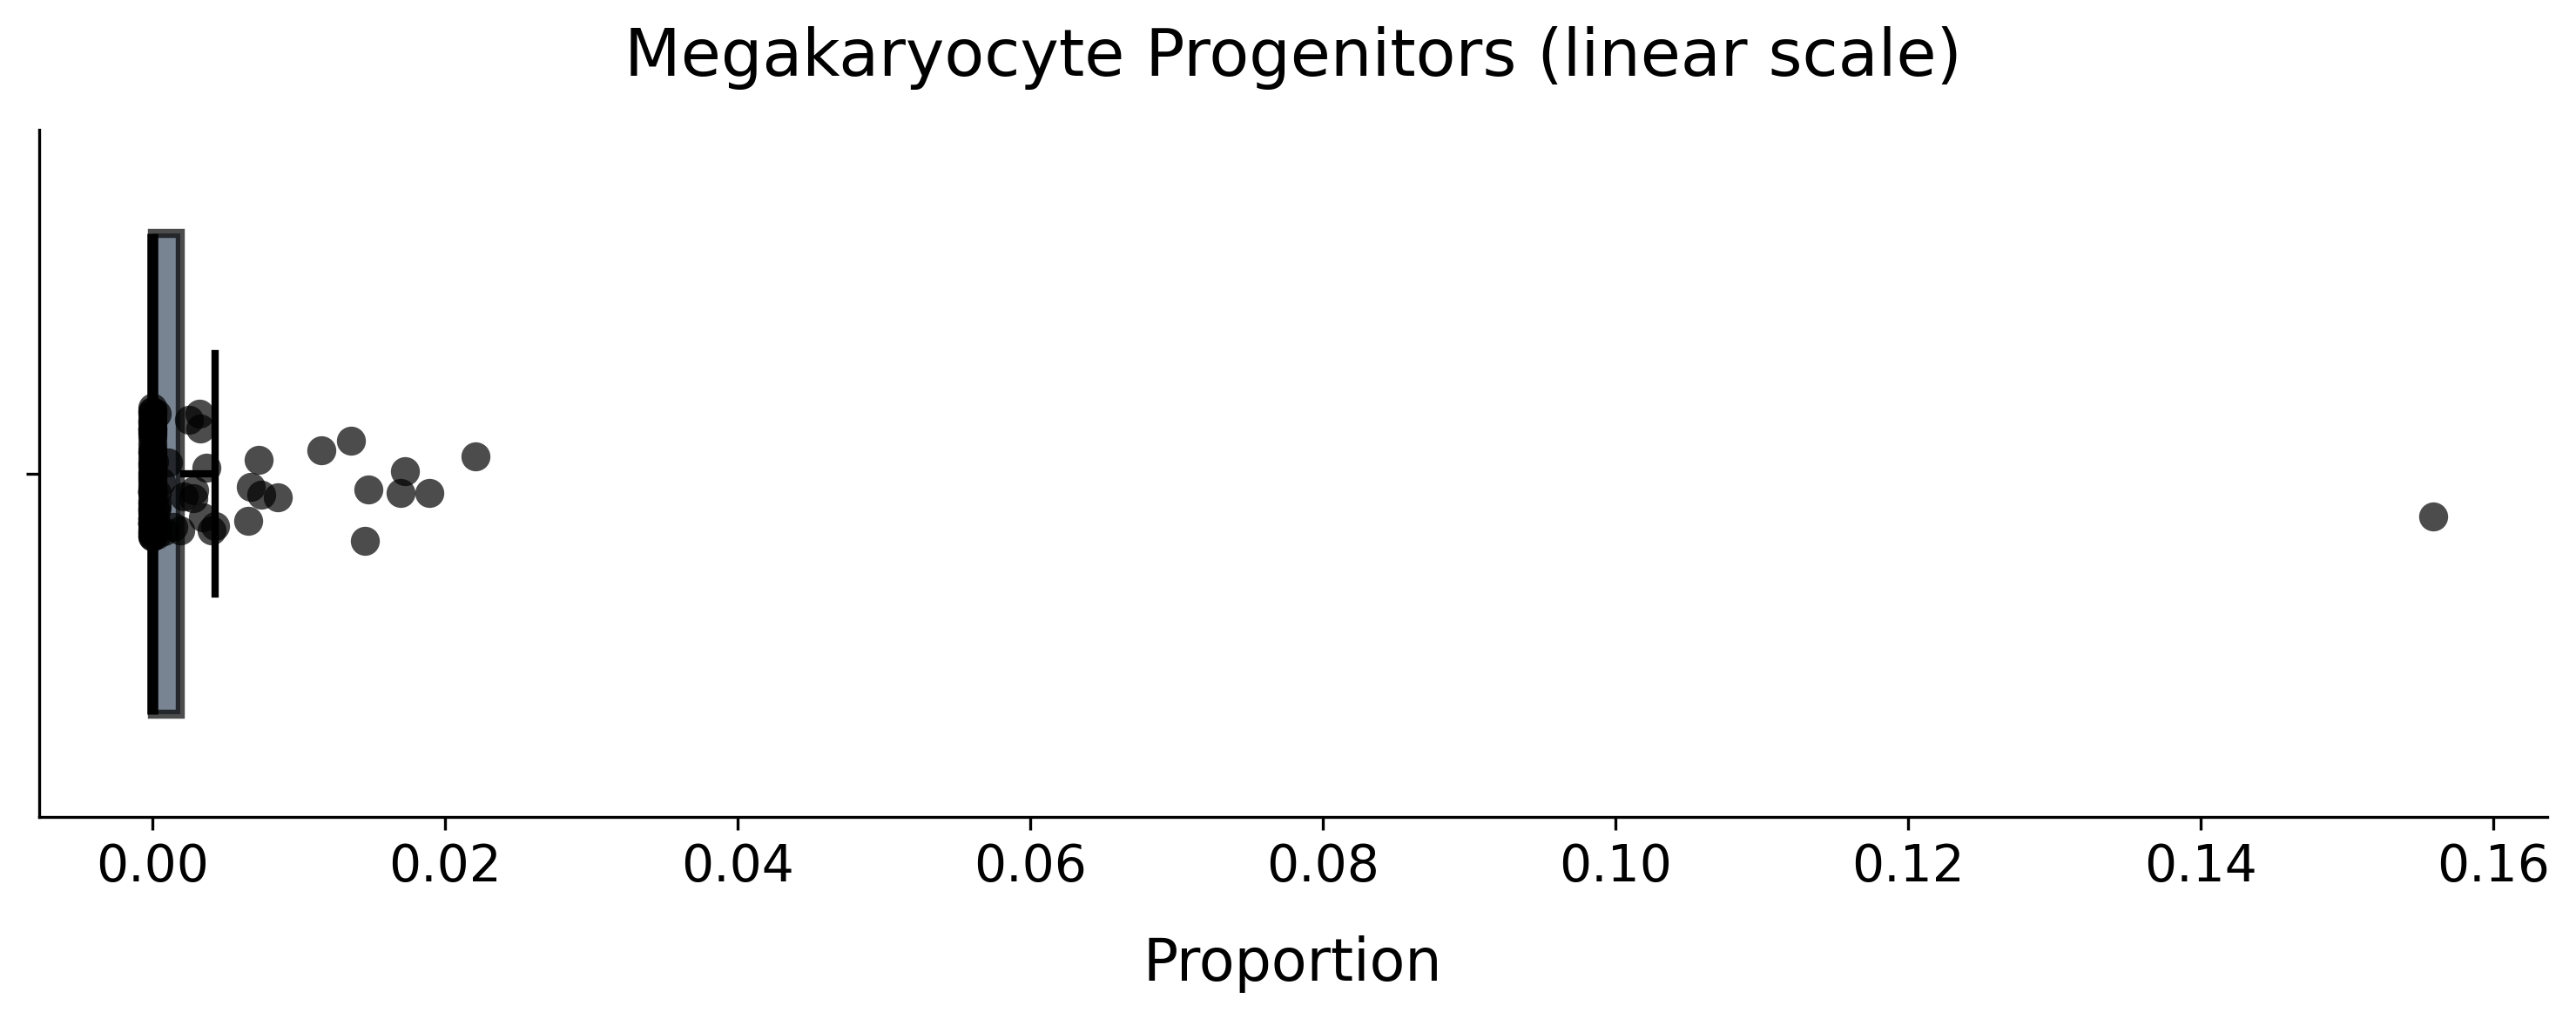

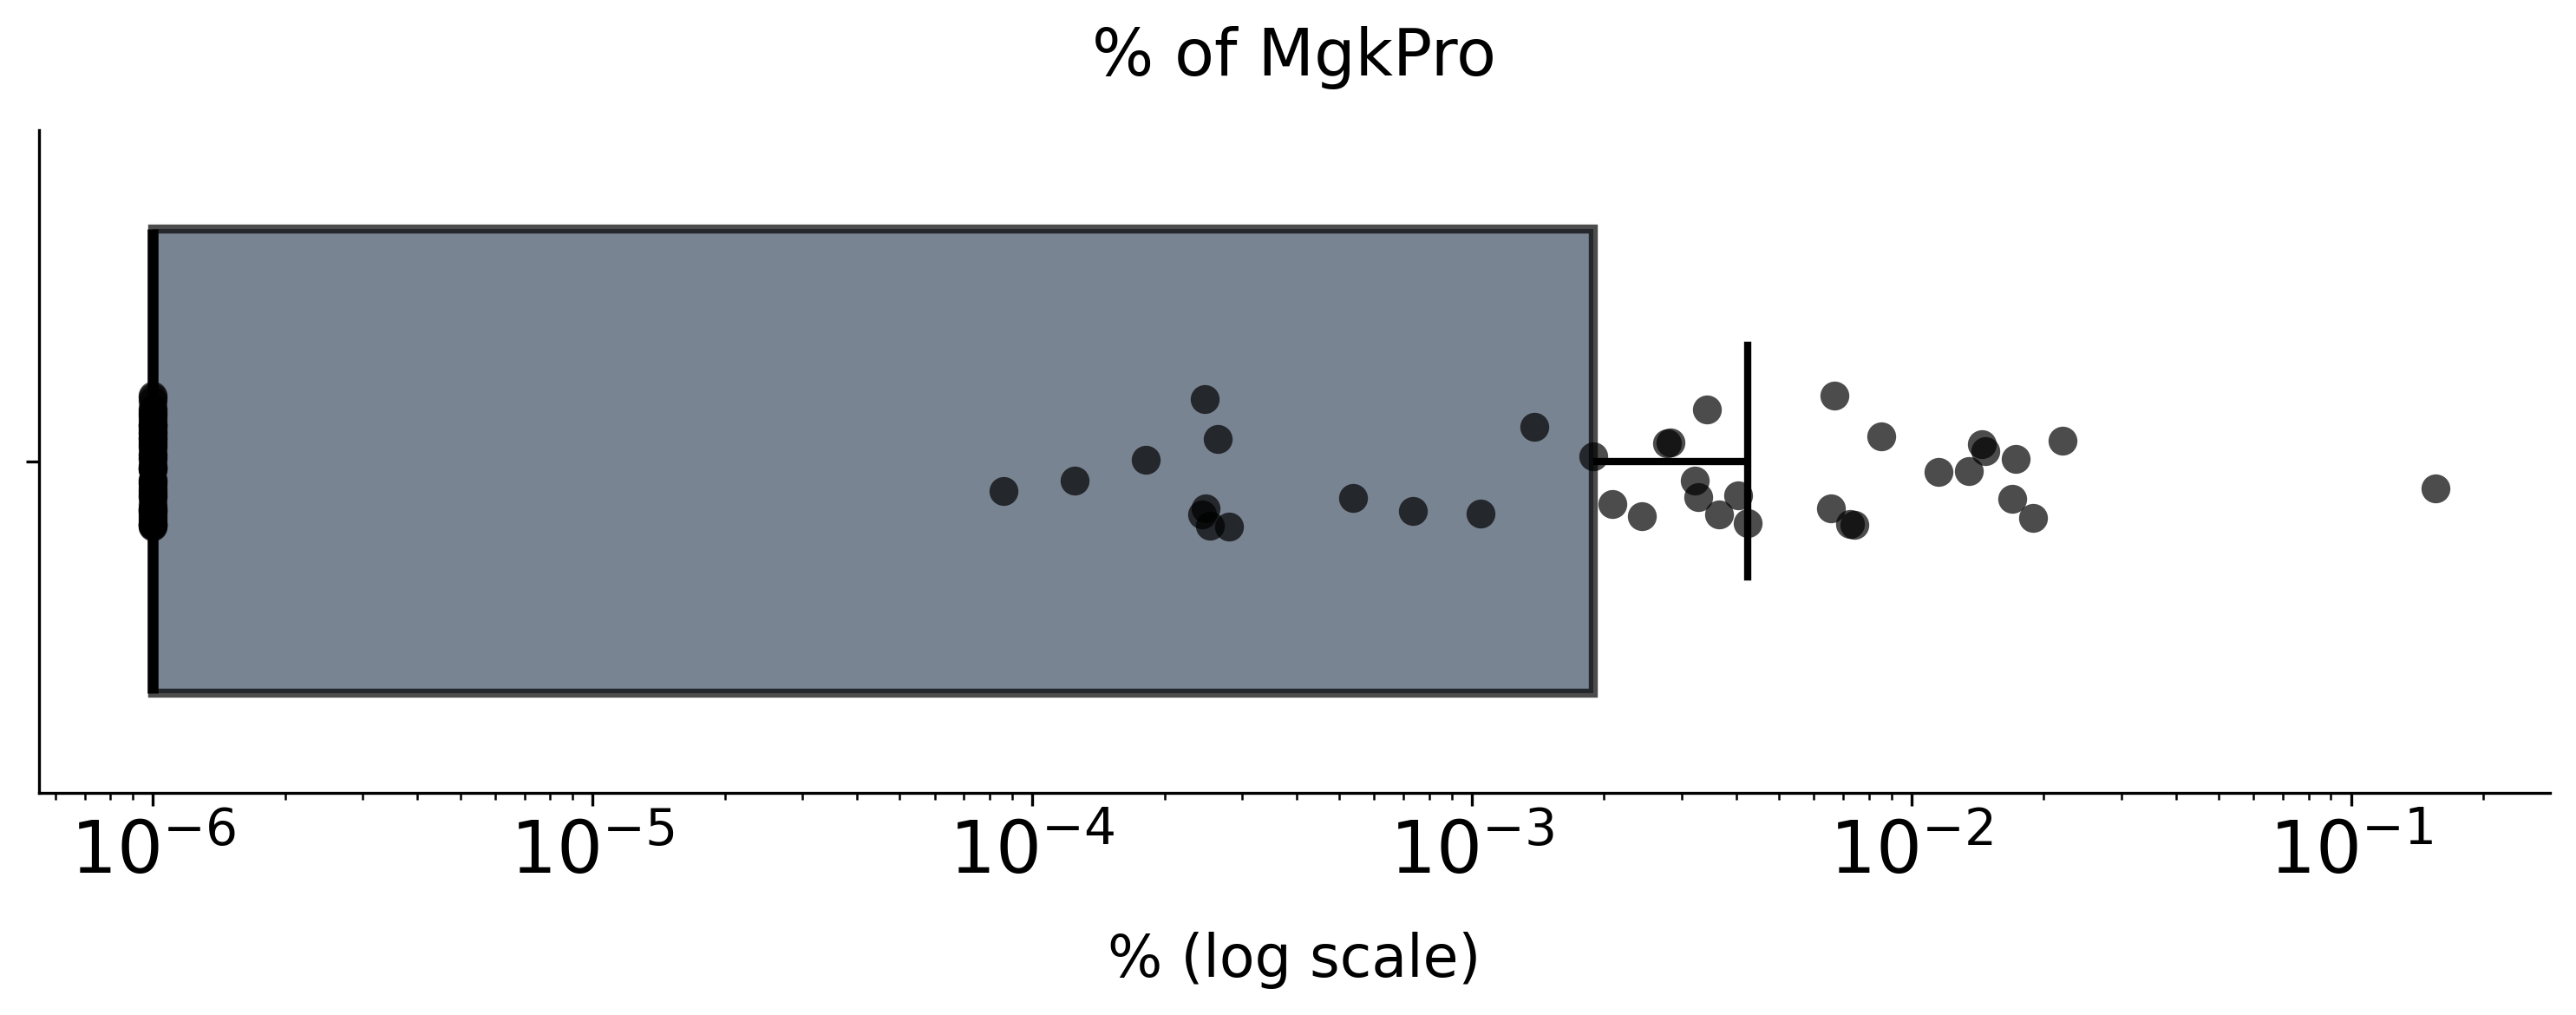

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your colour for late_MgkPro
color = color_map["late_MgkPro"]

# Prepare data (old only)
df_old = pd.DataFrame({'proportion': concs_df['late_MgkPro_prop']})

# ----------------------------------------------------------------------
# Figure 1: Horizontal boxplot – linear scale (huge font, fat layout)
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 4), dpi=300)      # wide figure, moderate height

# Horizontal boxplot (x = proportion, no y variable)
box = sns.boxplot(data=df_old, x='proportion', color=color, width=0.7,
                  boxprops=dict(alpha=0.7, edgecolor='black', linewidth=2.5),
                  whiskerprops=dict(color='black', linewidth=2),
                  capprops=dict(color='black', linewidth=2),
                  medianprops=dict(color='black', linewidth=3),
                  flierprops=dict(marker='none'))

# Add jittered points (horizontal jitter is automatic for x)
sns.stripplot(data=df_old, x='proportion', color='black',
              alpha=0.7, size=8, jitter=True)

# Huge fonts for everything
plt.xlabel('Proportion', fontsize=16, labelpad=12)
plt.title('Megakaryocyte Progenitors (linear scale)', fontsize=18, pad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)   # though y-axis has no labels, keep for consistency

sns.despine()
plt.tight_layout()
plt.savefig('../plots/boxplot_horizontal_linear_old_data.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# Figure 2: Horizontal boxplot – log scale (huge font, handling zeros)
# ----------------------------------------------------------------------
df_old_log = df_old.copy()
df_old_log['proportion'] = df_old_log['proportion'].clip(lower=1e-6)

plt.figure(figsize=(10, 4), dpi=300)

box = sns.boxplot(data=df_old_log, x='proportion', color=color, width=0.7,
                  boxprops=dict(alpha=0.7, edgecolor='black', linewidth=2.5),
                  whiskerprops=dict(color='black', linewidth=2),
                  capprops=dict(color='black', linewidth=2),
                  medianprops=dict(color='black', linewidth=3),
                  flierprops=dict(marker='none'))

sns.stripplot(data=df_old_log, x='proportion', color='black',
              alpha=0.7, size=8, jitter=True)

plt.xscale('log')
plt.xlabel('% (log scale)', fontsize=16, labelpad=12)
plt.title(r'% of MgkPro', fontsize=18, pad=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

sns.despine()
plt.tight_layout()
plt.savefig('../plots/boxplot_horizontal_log_old_data.png', dpi=300, bbox_inches='tight')
plt.show()


## Panel D: Visualize Candidates without LPHO012.

### Read Candidates Data.

In [15]:
candidates_base_dir = "../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official"
opt_modes_list = os.listdir(candidates_base_dir)

all_records = []
for opt_mode in opt_modes_list:
    opt_mode_base_dir = os.path.join(
        candidates_base_dir, opt_mode, "late_MgkPro"
    )

    runs_list = os.listdir(opt_mode_base_dir)

    for run_id in runs_list:
        candidates_csv_path = os.path.join(opt_mode_base_dir, run_id, "uncertainty_annotation", "candidates_with_uncertainties.csv")
        candidates_csv = pd.read_csv(candidates_csv_path)

        candidates_csv["run"] = run_id
        candidates_csv["opt_mode"] = opt_mode
        
        all_records.append(candidates_csv)
candidates_df = pd.concat(all_records, axis=0)
candidates_df

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,0,late_MgkPro:2026-04-29_18-14-46_5621f33b:0,3.217864,1.232483,0.224321,0.018293,1.352498,0.003009,0.000000,0.015023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,late_MgkPro:2026-04-29_18-14-46_5621f33b:1,5.733731,0.009683,384.913100,251.420170,0.000000,0.000000,114.951430,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,late_MgkPro:2026-04-29_18-14-46_5621f33b:2,10.162149,2.517613,295.627960,419.409900,0.041926,47.539024,0.071713,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,late_MgkPro:2026-04-29_18-14-46_5621f33b:3,9.609956,2.409408,563.735600,0.072564,0.865486,46.549767,0.076597,0.160119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,late_MgkPro:2026-04-29_18-14-46_5621f33b:4,9.718867,2.601944,880.871460,1194.650600,0.037637,54.538450,0.000000,0.221980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,45,late_MgkPro:2026-04-30_01-06-45_f4f22cca:45,8.868985,0.877943,191.139310,0.147150,0.662970,57.968956,0.315657,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,46,late_MgkPro:2026-04-30_01-06-45_f4f22cca:46,21.061314,4.431772,702.962460,77.849640,0.000000,17.754110,0.000000,3.586815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,47,late_MgkPro:2026-04-30_01-06-45_f4f22cca:47,10.362461,2.918244,340.193540,455.833530,0.124464,48.637047,0.558616,0.605150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,48,late_MgkPro:2026-04-30_01-06-45_f4f22cca:48,8.507112,3.579082,101.002190,371.961580,0.000000,42.998966,0.000000,1.272915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter out Unfeasible Candidates.

In [16]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 37200 ---
			 --- Number Currently Accepted Solutions 34785 ---
			 --- Number of Solution Satisfying Upper Bound 34785 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 34785 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 37200 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 34785 ---
			 --- Number Currently Accepted Solutions 30333 ---
			 --- Number of Solution Satisfying Upper Bound 31757 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 30333 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 34785 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

### Filtering Bad Solutions.

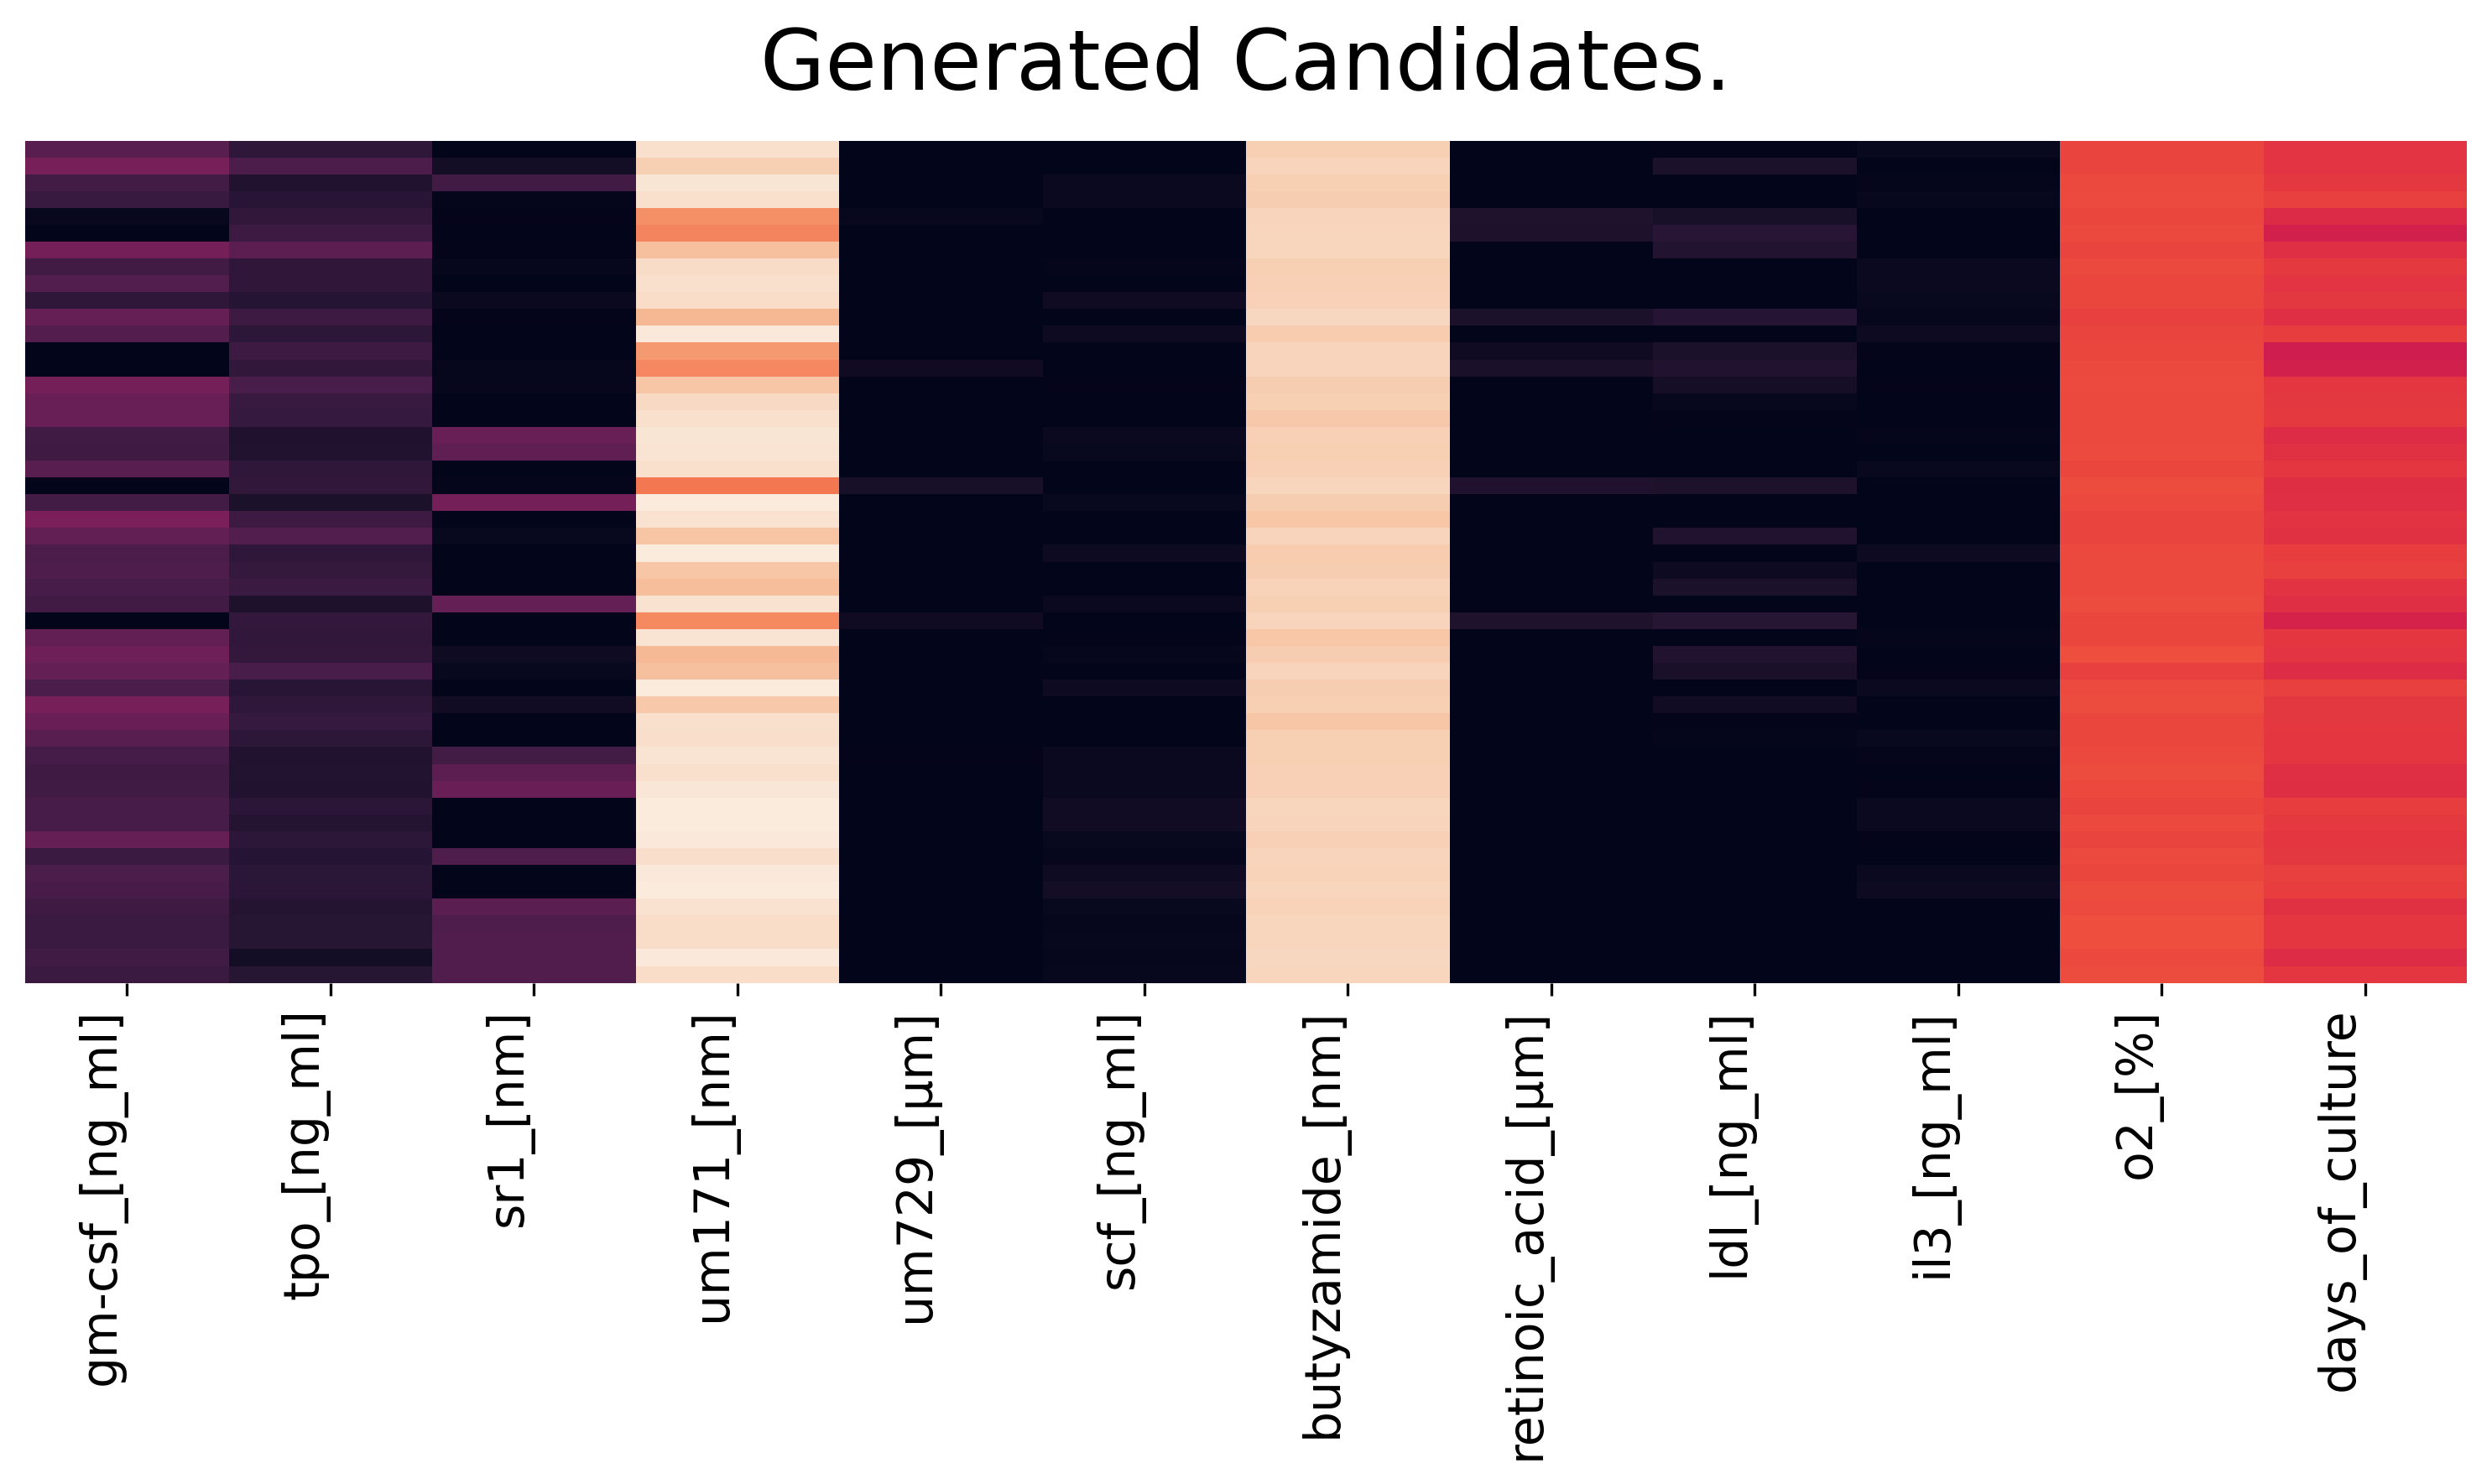

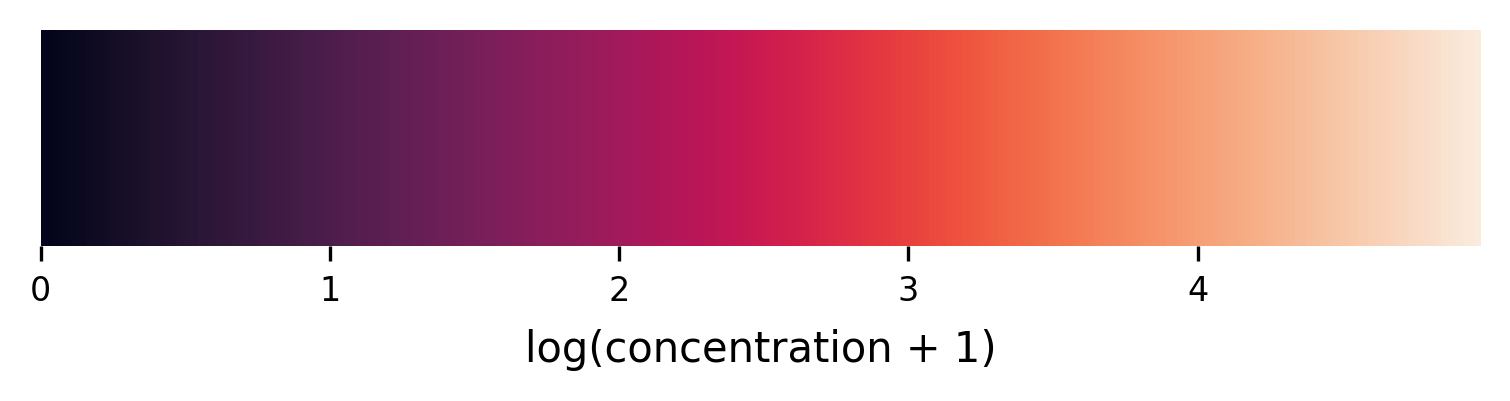

In [17]:
# ------------------------------------------------------------------
# 1. Prepare the data (unchanged)
# ------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
mgk_enriching_mask = (filtered_candidates_df["late_MgkPro_prop"] > 0.15)
filtered_candidates_df = filtered_candidates_df[mgk_enriching_mask]
filtered_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1))

# Determine global min/max for consistent colour scaling
vmin = filtered_concs.min().min()
vmax = filtered_concs.max().max()
cmap = 'rocket'  # or 'plasma', 'rocket', etc. – match your heatmap

# ------------------------------------------------------------------
# 2. Main heatmap (without colorbar)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=300)
ax = sns.heatmap(
    filtered_concs,
    annot=False,
    fmt='.2f',
    linewidths=0.0,
    linecolor='black',
    cbar=False,               # disable the built‑in colorbar
    vmin=vmin, vmax=vmax,
    cmap=cmap
)

# Remove y‑axis ticks and labels
ax.set_yticklabels([])
ax.tick_params(axis='y', left=False)

# Rotate x‑labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=14)

# Add title
plt.title('Generated Candidates.', fontsize=24, pad=15)

plt.tight_layout()
plt.savefig('../plots/filtered_concentrations_heatmap_old_data.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# 3. Save the colorbar separately (fat and short, horizontal)
# ------------------------------------------------------------------
fig_cbar = plt.figure(figsize=(6, 1.2), dpi=300)   # wide and short
ax_cbar = fig_cbar.add_axes([0.1, 0.2, 0.8, 0.6])  # [left, bottom, width, height]

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)
cbar.ax.tick_params(labelsize=8)

# Remove the frame around the colorbar axis
ax_cbar.set_frame_on(False)

fig_cbar.savefig('../plots/heatma_colorbar_separate_old.png', bbox_inches='tight', dpi=300)
plt.show()


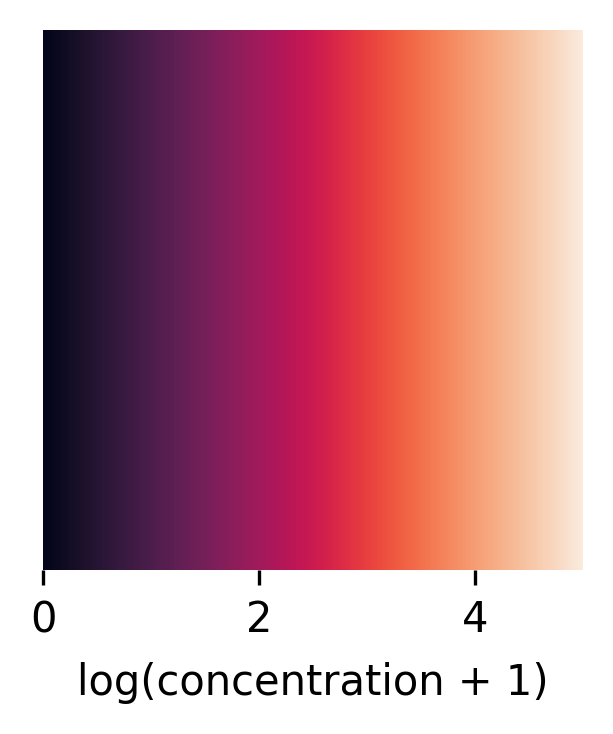

In [18]:
# ------------------------------------------------------------------
# 3. Save the colorbar separately (vertical, fatty, bigger font, ticks 0,2,4)
# ------------------------------------------------------------------
fig_cbar = plt.figure(figsize=(3, 2), dpi=300)          # 2″ wide, 3″ tall
ax_cbar = fig_cbar.add_axes([0.2, 0.05, 0.6, 0.9])     # [left, bottom, width, height]
# Increase width to 0.8 for an even fatter bar:
# ax_cbar = fig_cbar.add_axes([0.1, 0.05, 0.8, 0.9])

vmin = 0.0
vmax = 5.0
cmap = 'rocket'

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')

# Set custom ticks and labels with larger font
cbar.set_ticks([0, 2, 4])
cbar.set_ticklabels(['0', '2', '4'], fontsize=10)   # bigger tick labels

cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)   # bigger label, more space
cbar.ax.tick_params(labelsize=10)                  # ensure ticks are also 10pt

# Remove outline and frame
cbar.outline.set_visible(False)
ax_cbar.set_frame_on(False)

fig_cbar.savefig('../plots/heatma_colorbar_separate_old.png', bbox_inches='tight', dpi=300)
plt.show()


## Panel E: Effect of Inclusion of Sakurai Medium. 

### Umap of New Data.

Updated color for late_MgkPro to #3a4f6a


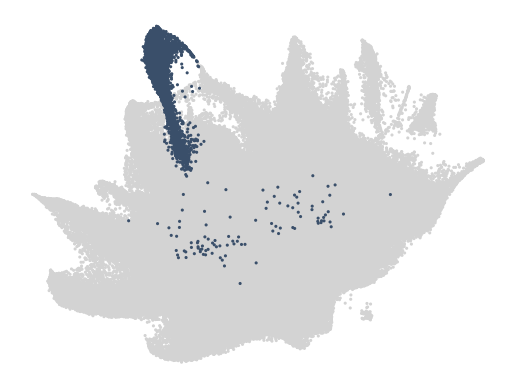

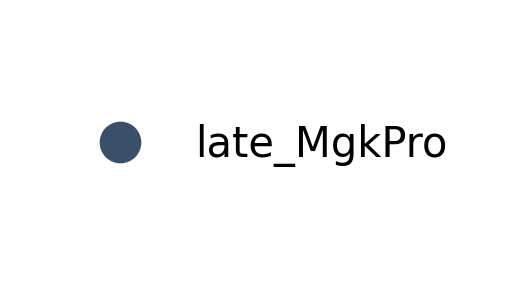

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc

# ----------------------------------------------------------------------
# 1. Ensure the color for 'late_MgkPro' is correctly set
# ----------------------------------------------------------------------
if not isinstance(adata_new.uns.get('cell_type_colors'), list):
    categories = adata_new.obs['cell_type'].cat.categories
    old_colors = adata_new.uns.get('cell_type_colors', {})
    adata_new.uns['cell_type_colors'] = [
        old_colors.get(ct, '#cccccc') if isinstance(old_colors, dict) else '#cccccc'
        for ct in categories
    ]

cell_type_colors = adata_new.uns['cell_type_colors']
categories = adata_new.obs['cell_type'].cat.categories.tolist()

target_cell = 'late_MgkPro'
if target_cell in categories:
    idx = categories.index(target_cell)
    cell_type_colors[idx] = '#3a4f6a'
    print(f"Updated color for {target_cell} to #3a4f6a")
else:
    print(f"'{target_cell}' not found in categories. Available: {categories}")

# ----------------------------------------------------------------------
# 2. Plot UMAP with only the dots (no legend, no axes, no labels)
# ----------------------------------------------------------------------
ax = sc.pl.umap(
    adata_new,
    color="cell_type",
    s=20,
    groups=["late_MgkPro"],
    show=False,
    frameon=False,          # remove the frame box
    legend_loc='none',      # remove legend
    title=''                # remove title
)

# If the return is a list of Axes (for multiple panels), take the first one
if isinstance(ax, list):
    ax = ax[0]

# Remove all ticks and tick labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

# Set axis labels to empty strings (explicitly)
ax.set_xlabel('')
ax.set_ylabel('')

# Remove the four spines (though frameon=False already removes them, this is safe)
for spine in ax.spines.values():
    spine.set_visible(False)

# Save high-quality figure (only dots)
plt.savefig(
    '../plots/umap_late_MgkPro_new_data.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------------------------------------------------
# Save the legend separately (with a DOT / circle marker)
# ----------------------------------------------------------------------
legend_handle = Line2D([0], [0], marker='o', color='none', 
                       markerfacecolor='#3a4f6a', markersize=10,
                       markeredgecolor='none', label='late_MgkPro')

fig_legend = plt.figure(figsize=(2, 1), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=[legend_handle], loc='center', frameon=False)
fig_legend.savefig('../plots/umap_legend_separate.png', bbox_inches='tight', dpi=300)
plt.show()



### Frequency of MgkPros Across Conditions.

In [20]:
# get unique concentrations
unique_concs = np.unique(adata_new.obs[protocol_cols].astype(float).values, axis=0)
concs_df_new = pd.DataFrame(unique_concs, columns=protocol_cols)

# compute proportions
props = []
for idx, row in tqdm(concs_df_new.iterrows()):
    # slice adata for current experiment
    row_vals = row.values
    rmask = np.all(adata_new.obs[protocol_cols].astype(float).values == row_vals, axis=1)
    radata = adata_new[rmask]
    nexp = rmask.sum()

    # compute conts of MgkPro
    ct_mask = radata.obs.cell_type == "late_MgkPro"
    n_ct = ct_mask.sum()

    # proportion
    ct_prop = (n_ct / nexp).item()
    props.append(ct_prop)
concs_df_new["late_MgkPro_prop"] = props
concs_df_new["condition"] = np.arange(len(concs_df_new))

103it [00:02, 37.99it/s]


### Plot Frequency.

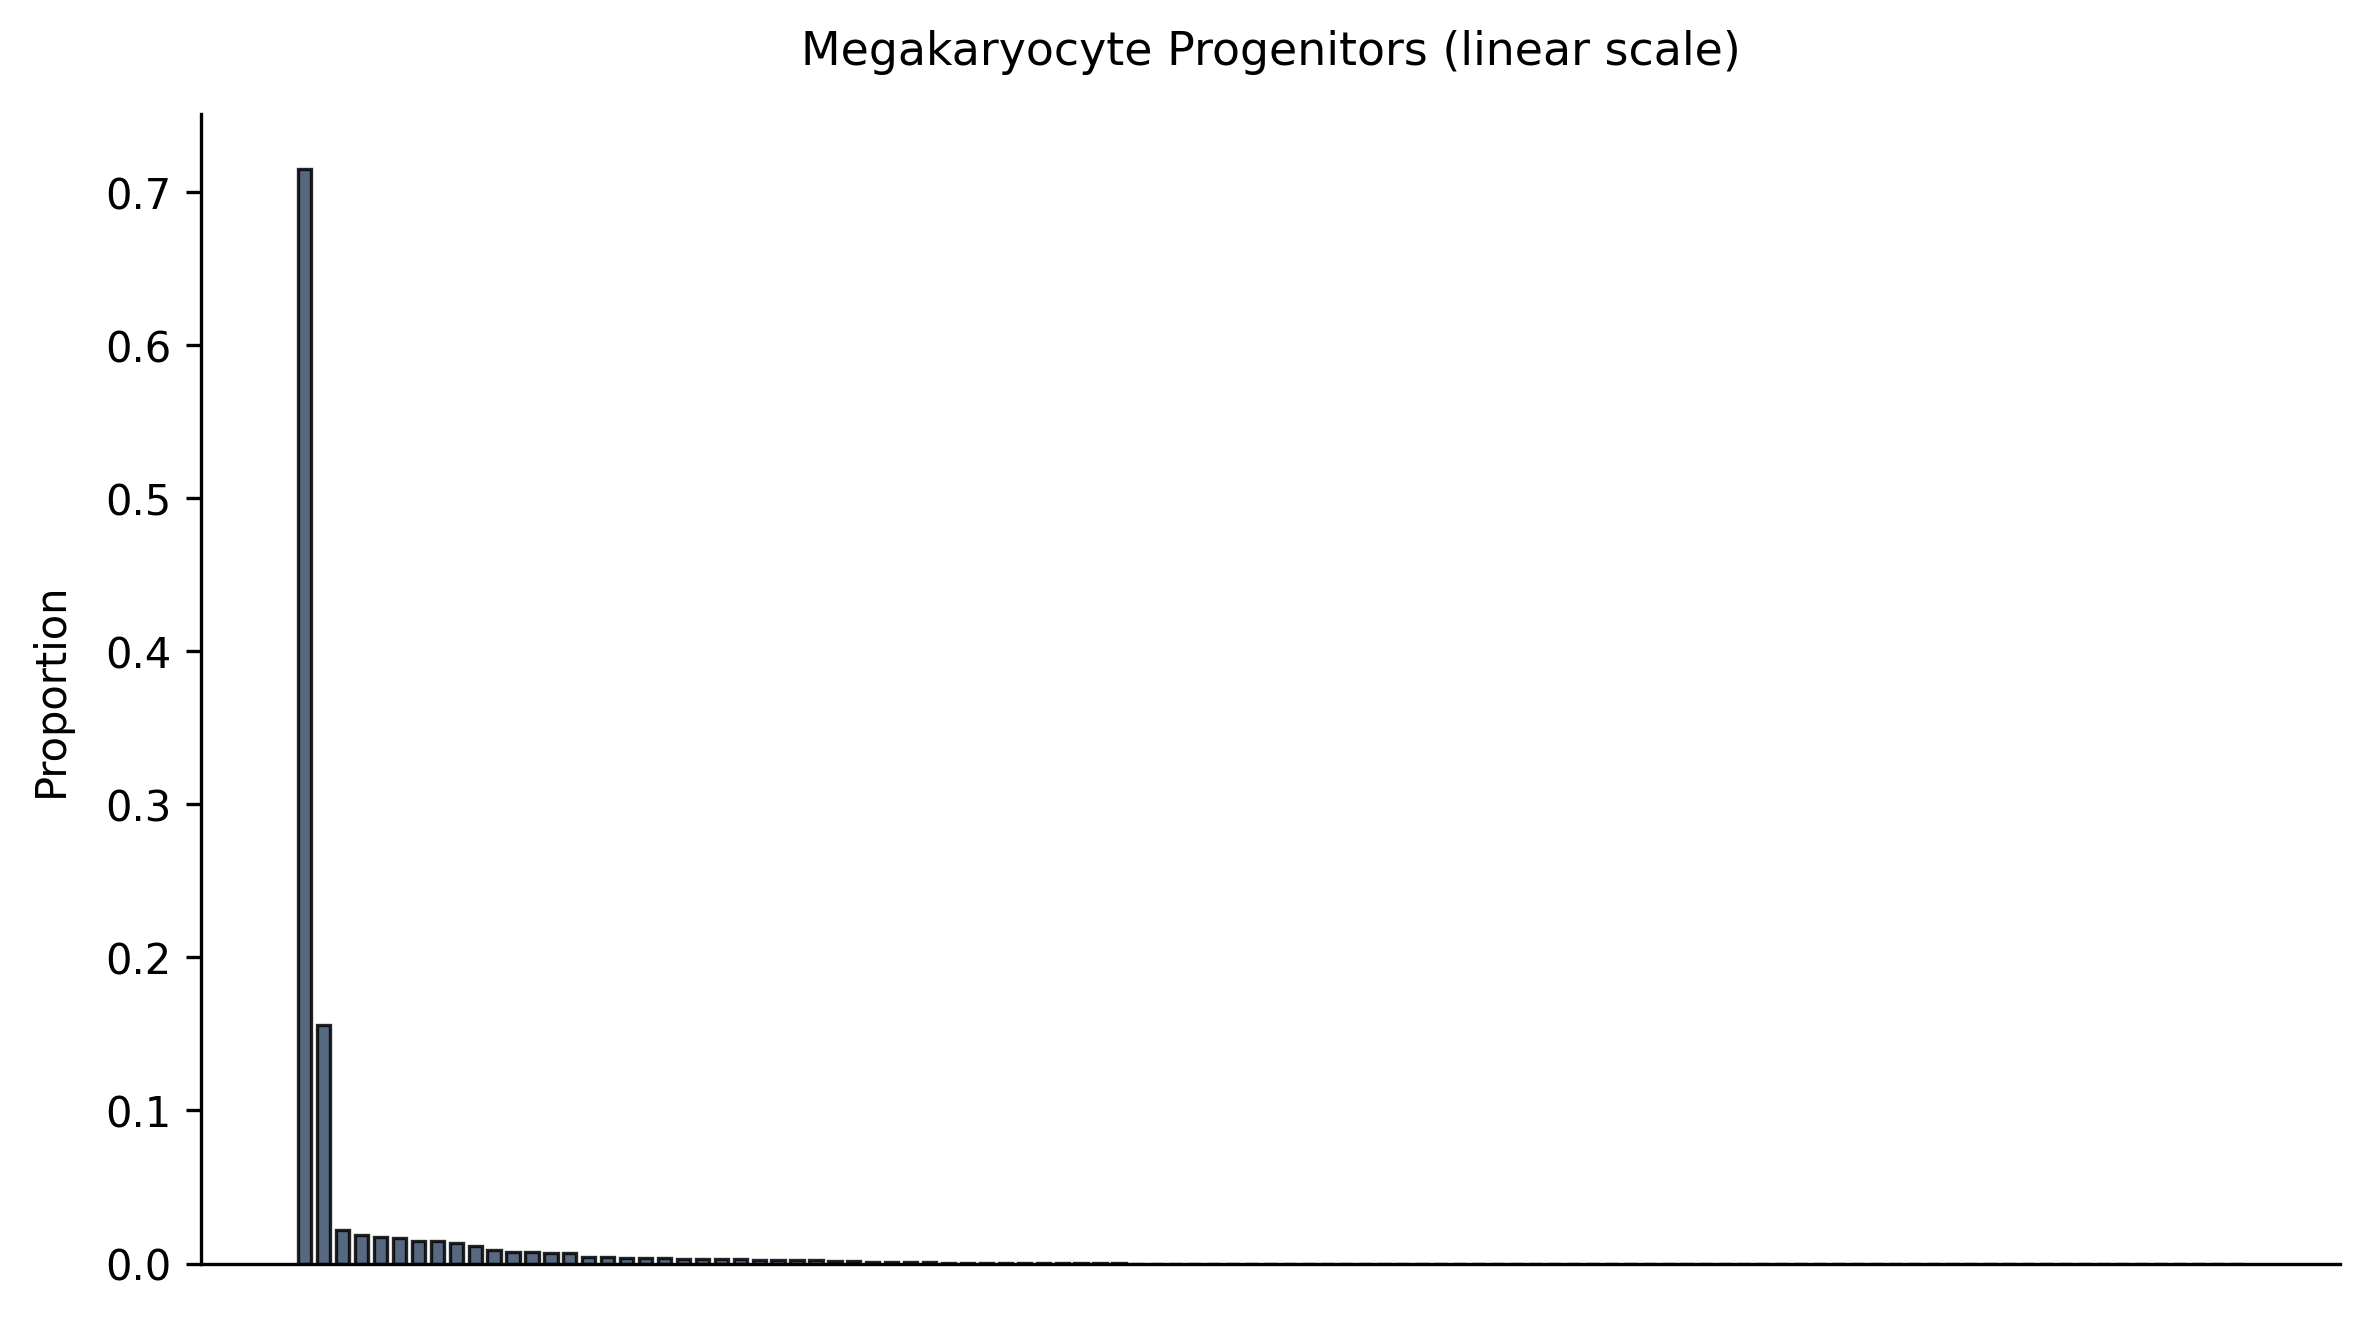

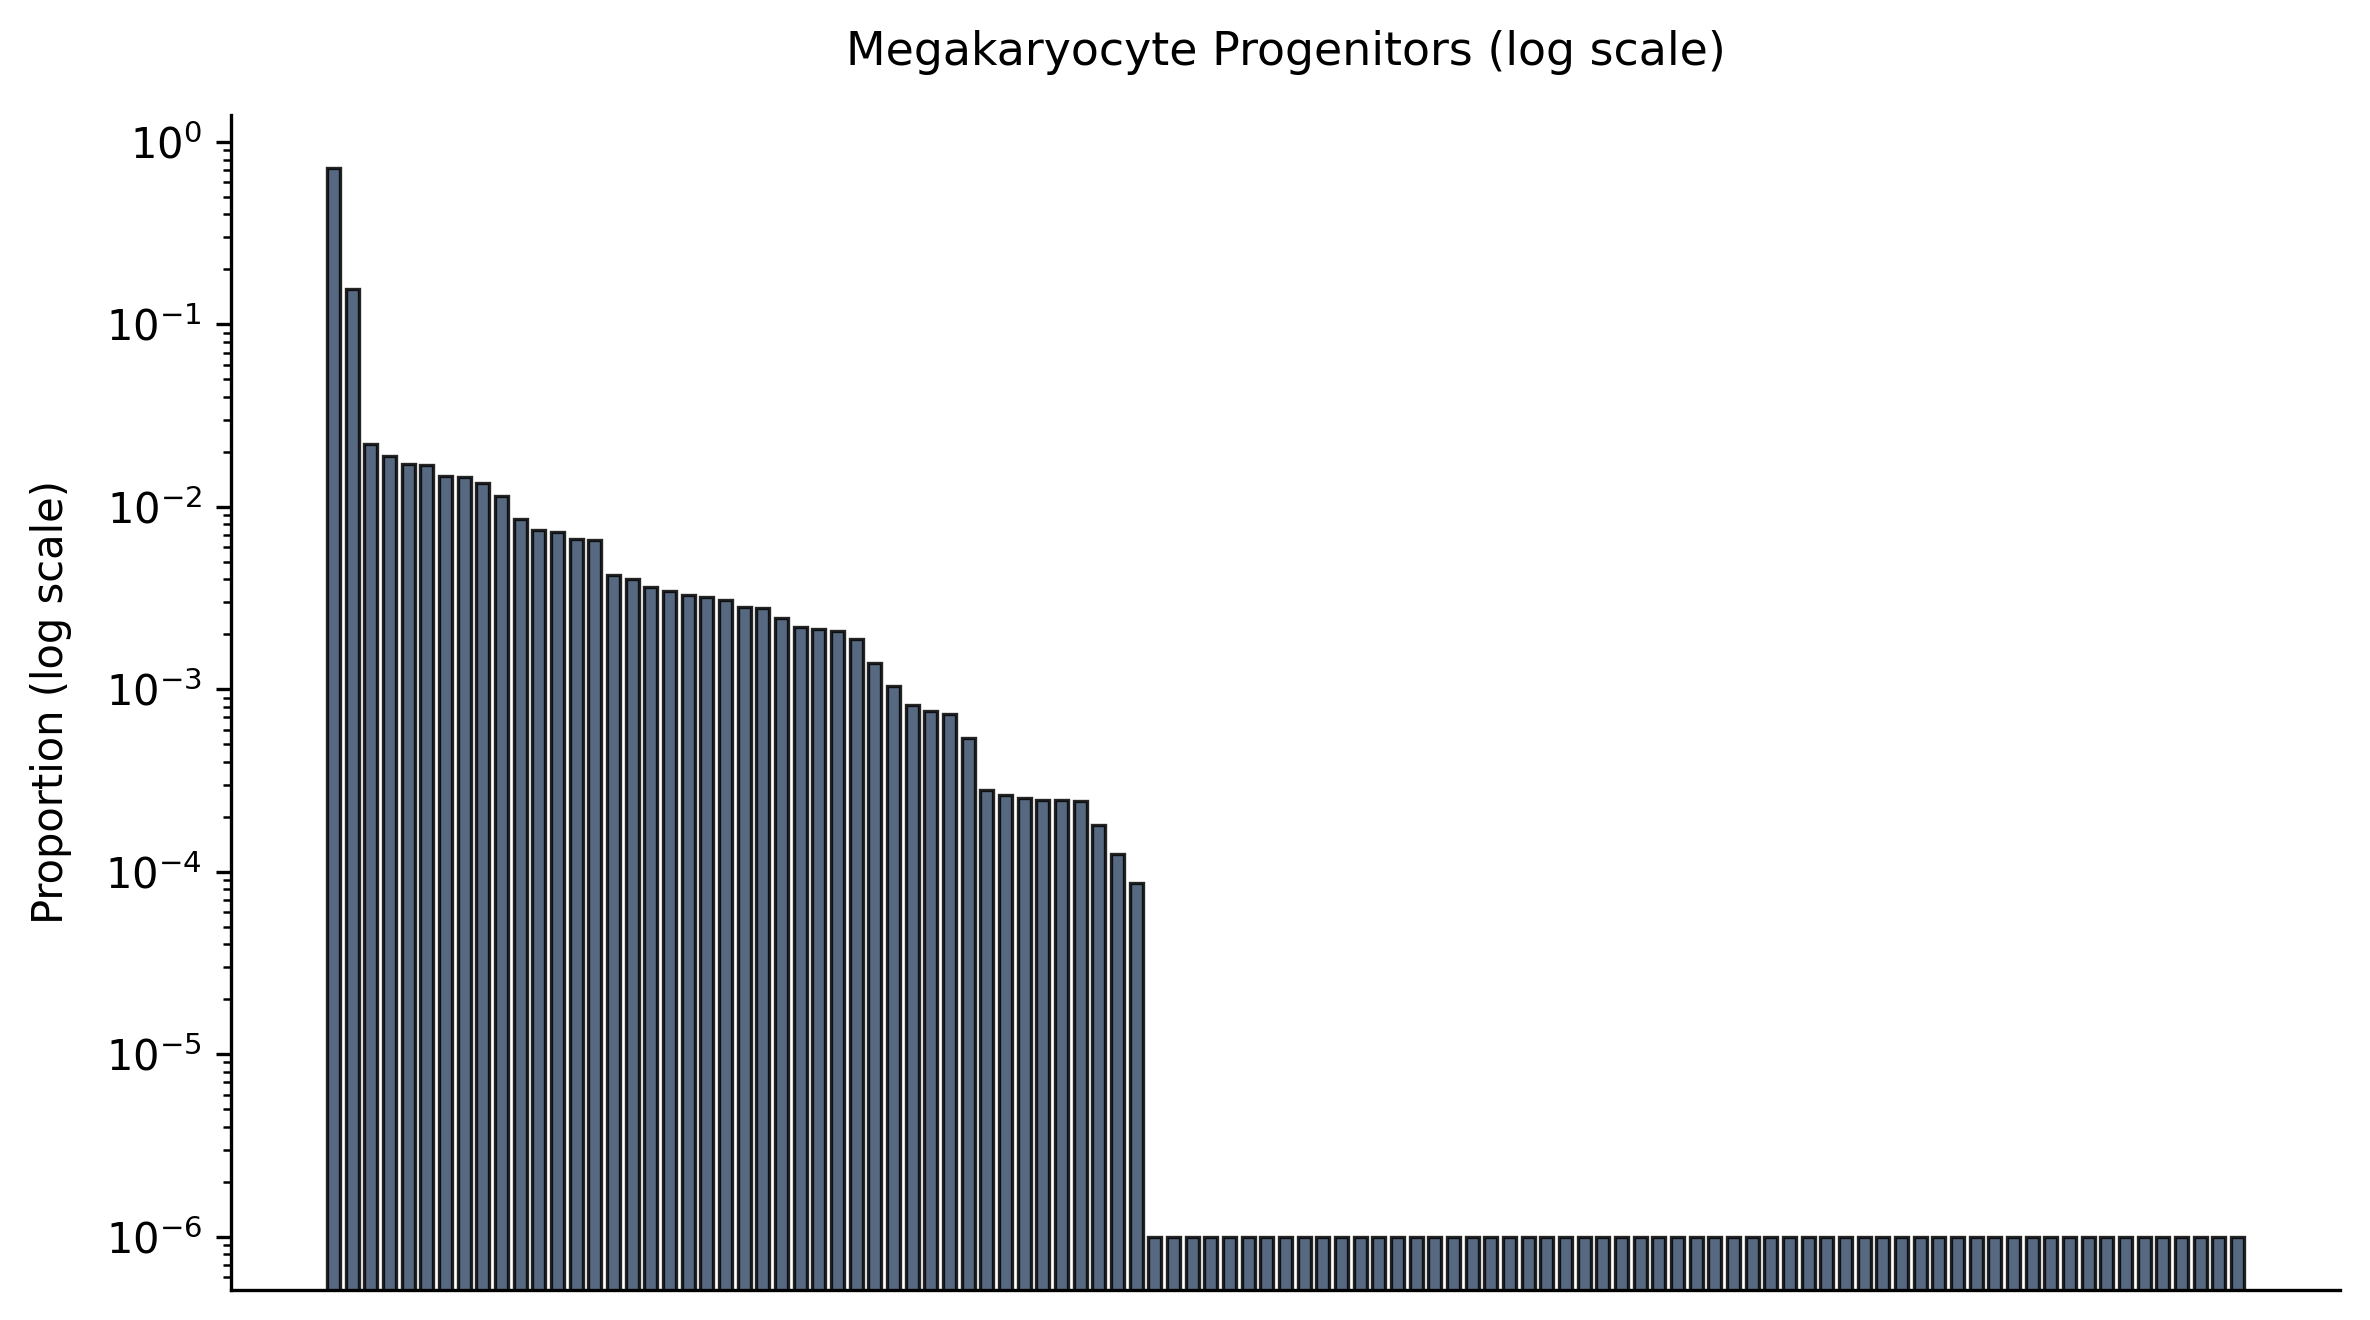

In [21]:
# Your colour for late_MgkPro
color = color_map["late_MgkPro"]

# Prepare sorted data
concs_df_sorted_new = concs_df_new.sort_values('late_MgkPro_prop', ascending=False).reset_index(drop=True)
x_values = range(len(concs_df_sorted_new))

# ----------------------------------------------------------------------
# Figure 1: Linear scale (stylized)
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 4.5), dpi=300)

bars = plt.bar(x_values, concs_df_sorted_new['late_MgkPro_prop'],
               width=0.7,
               color=color,
               edgecolor='black',
               linewidth=0.8,
               alpha=0.85,
               zorder=2)

# Remove x‑ticks and labels
plt.xticks([])
plt.tick_params(axis='x', length=0)


# Labels and title
plt.ylabel('Proportion', fontsize=10, labelpad=8)
plt.title('Megakaryocyte Progenitors (linear scale)', fontsize=11, pad=12)

# Remove top/right spines
sns.despine()

# Optionally add value labels on top of bars (choose a few to avoid clutter)
# Uncomment if you want labels for all bars:
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
#              f'{height:.2f}', ha='center', va='bottom', fontsize=5)

plt.tight_layout()
plt.savefig('../plots/proportion_late_MgkPro_linear_new_data.png', bbox_inches='tight', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# Figure 2: Log scale (stylized, handling zeros)
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 4.5), dpi=300)

# Replace 0 with a small positive value for log plotting (1e-6)
y_log = concs_df_sorted_new['late_MgkPro_prop'].clip(lower=1e-6)

bars = plt.bar(x_values, y_log,
               width=0.7,
               color=color,
               edgecolor='black',
               linewidth=0.8,
               alpha=0.85,
               zorder=2)

plt.xticks([])
plt.tick_params(axis='x', length=0)
plt.yscale('log')

plt.ylabel('Proportion (log scale)', fontsize=10, labelpad=8)
plt.title('Megakaryocyte Progenitors (log scale)', fontsize=11, pad=12)

sns.despine()
plt.tight_layout()
plt.savefig('../plots/proportion_late_MgkPro_log_new_data.png', bbox_inches='tight', dpi=300)
plt.show()



### Plot Cell Type Proportions for Sakurai.

/tmp/ipykernel_3076356/3704134193.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3076356/3704134193.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=18, rotation=90, ha="right")
/tmp/ipykernel_3076356/3704134193.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels, size=18)


<class 'list'>
8


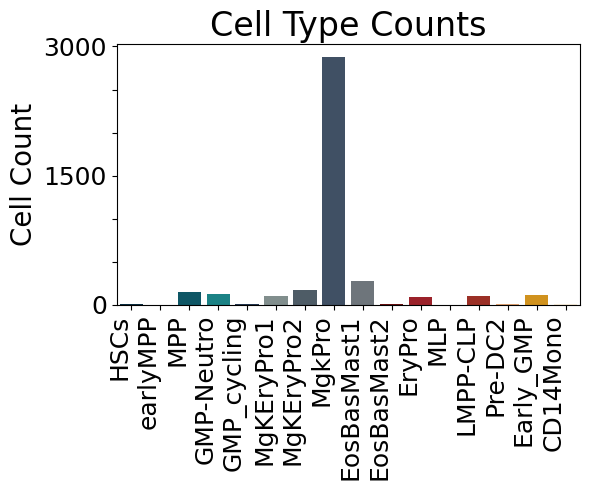

In [22]:
adata_sakurai = adata_new[
    adata_new.obs.experiment_number == 210
]
adata_sakurai

counts = (
    adata_sakurai.obs["cell_type"]
    .value_counts()
    .reset_index()
)
counts.columns = ["cell_type", "count"]

rename_map = {
    "late_MgkPro": "MgkPro",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
}

counts.cell_type = counts.cell_type.map(
    lambda x: rename_map.get(x, x)
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=counts,
    y="count",
    x="cell_type",
    palette={ct: color_map[ct] for ct in counts["cell_type"]},
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Cell Count", size=20)
ax.set_title("Cell Type Counts", size=24)
# ax.set_yscale("log")
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), size=18, rotation=90, ha="right")
yticklabels = ax.get_yticklabels()

yticklabels = [""]*len(yticklabels)
yticklabels[0] = 0
yticklabels[3] = 1500
yticklabels[6] = 3000
print(type(yticklabels))
print(len(yticklabels))

# ax.set_yticklabels(ax.get_yticklabels(), size=18)
ax.set_yticklabels(yticklabels, size=18)
plt.tight_layout()
plt.savefig("../plots/cell_type_counts_sakurai.svg")
plt.savefig("../plots/cell_type_counts_sakurai.png")
plt.show()



### Heatmap of Sakurai Concentrations.

/tmp/ipykernel_3076356/947390585.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


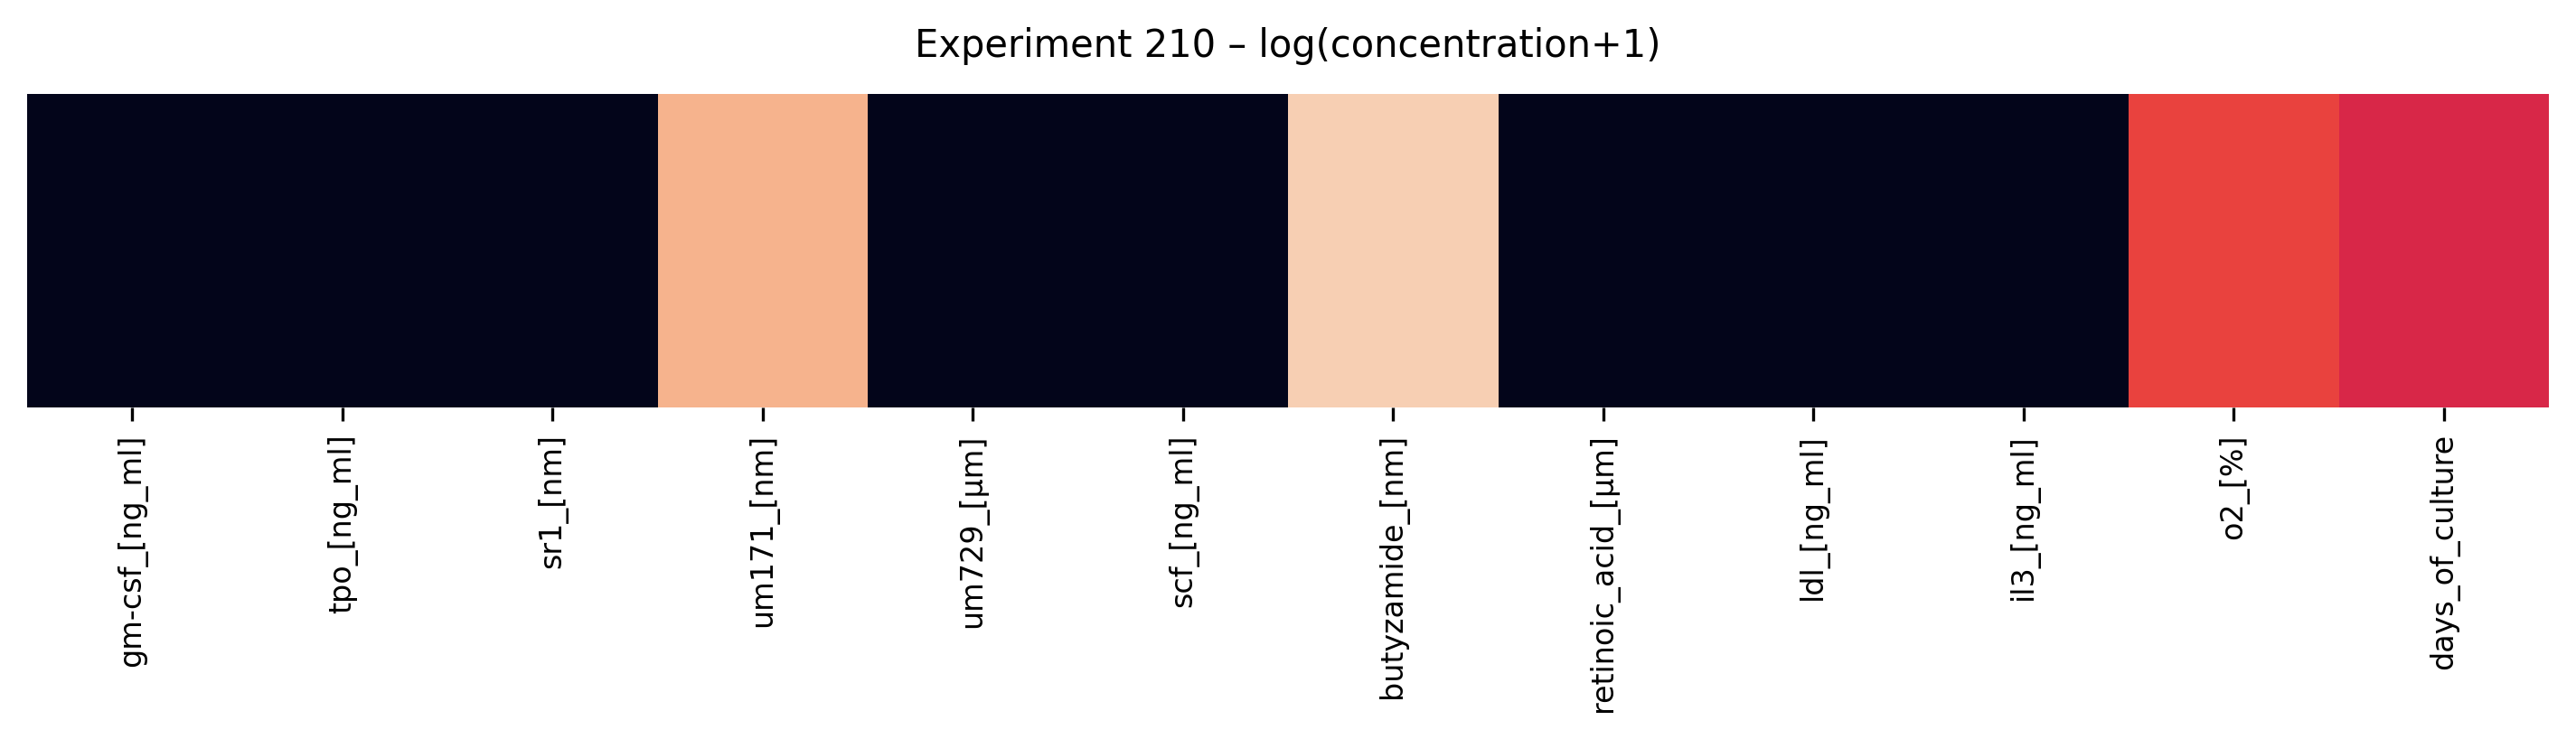

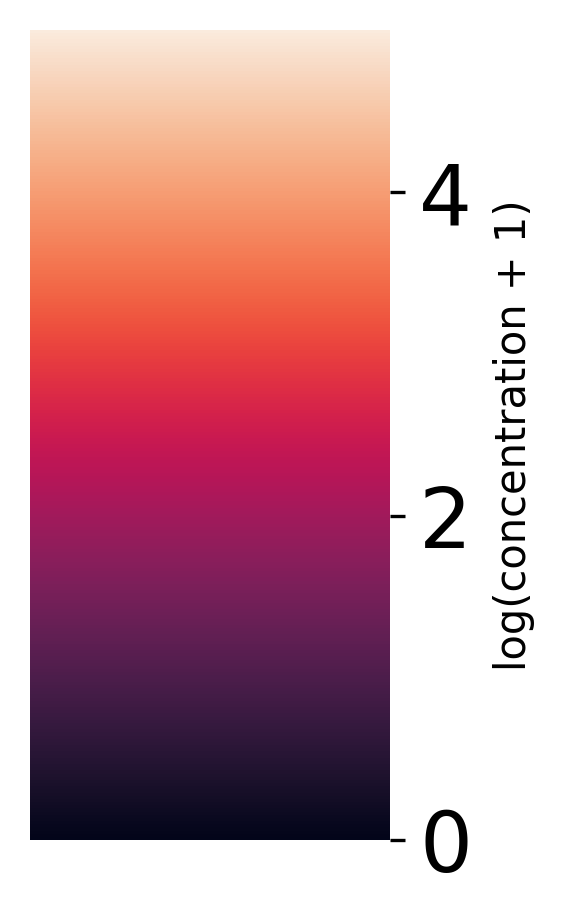

In [23]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# protocol_cols is already defined (list of column names)
# adata_sakurai is your subset for experiment 210

# Get the unique condition (take the first cell, all cells have the same value)
cond_vals = adata_sakurai.obs[protocol_cols].iloc[0].astype(float).values

# Log‑transform (log1p)
cond_log = [math.log(v + 1) for v in cond_vals]

# Create a 1‑row DataFrame for the heatmap
heatmap_df = pd.DataFrame([cond_log], columns=protocol_cols)

# Plot the heatmap (single row)
plt.figure(figsize=(12, 1.5), dpi=300)
ax = sns.heatmap(
    heatmap_df,
    annot=False,                # show numeric values
    fmt='.2f',
    cmap='rocket',
    cbar=False,                # no colorbar on the main plot
    linewidths=0.0,
    linecolor='black',
    vmin=0,                    # adjust if needed (min log concentration)
    vmax=5
)

# Style: remove y‑axis labels and ticks
ax.set_yticklabels([])
ax.tick_params(axis='y', left=False)
ax.set_ylabel('')

# Rotate x‑axis labels for readability
ax.set_xticklabels(protocol_cols, rotation=90, ha='center', fontsize=8)

plt.title(f'Experiment 210 – log(concentration+1)', fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('../plots/exp210_condition_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# If you need a separate colorbar (optional, same style as before)
# ------------------------------------------------------------------
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig_cbar = plt.figure(figsize=(2, 3), dpi=300)
ax_cbar = fig_cbar.add_axes([0.2, 0.05, 0.6, 0.9])
norm = Normalize(vmin=0, vmax=5)
sm = ScalarMappable(norm=norm, cmap='rocket')
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar, orientation='vertical')
cbar.set_ticks([0, 2, 4])
cbar.set_ticklabels(['0', '2', '4'], fontsize=20)
cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)
cbar.outline.set_visible(False)
ax_cbar.set_frame_on(False)
fig_cbar.savefig('../plots/exp210_colorbar.png', bbox_inches='tight', dpi=300)
plt.show()


### Read Candidates New Data.

In [24]:
candidates_base_dir = "../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_official"
opt_modes_list = os.listdir(candidates_base_dir)

all_records = []
for opt_mode in opt_modes_list:
    opt_mode_base_dir = os.path.join(
        candidates_base_dir, opt_mode, "late_MgkPro"
    )

    runs_list = os.listdir(opt_mode_base_dir)

    for run_id in runs_list:
        candidates_csv_path = os.path.join(opt_mode_base_dir, run_id, "uncertainty_annotation", "candidates_with_uncertainties.csv")
        candidates_csv = pd.read_csv(candidates_csv_path)

        candidates_csv["run"] = run_id
        candidates_csv["opt_mode"] = opt_mode
        
        all_records.append(candidates_csv)
candidates_df_new = pd.concat(all_records, axis=0)
candidates_df_new


,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,0,late_MgkPro:2026-04-21_16-11-15_04173209:0,10.028185,2.239812,679.62024,542.93100,0.001843,13.811527,0.000000,0.675606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,late_MgkPro:2026-04-21_16-11-15_04173209:1,10.170584,2.804203,838.66590,1124.17290,0.000000,47.934883,0.000000,0.132261,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,late_MgkPro:2026-04-21_16-11-15_04173209:2,9.332884,2.502338,684.25290,958.07170,0.077955,46.770470,0.000000,0.212369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,late_MgkPro:2026-04-21_16-11-15_04173209:3,9.511456,2.378527,694.14026,1269.83330,0.081972,47.827890,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,late_MgkPro:2026-04-21_16-11-15_04173209:4,10.602394,2.598344,325.38925,1078.82190,0.009989,43.626503,0.070183,0.103289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,late_MgkPro:2026-04-20_16-39-19_1ed015c2:95,9.247754,2.714940,499.18414,836.18760,0.000000,52.914906,0.000000,0.395746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,96,late_MgkPro:2026-04-20_16-39-19_1ed015c2:96,10.053179,2.217156,417.11722,462.04160,0.000000,27.468020,0.000000,0.258692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,late_MgkPro:2026-04-20_16-39-19_1ed015c2:97,10.239780,1.850118,560.01480,730.99010,0.000000,52.885746,0.983276,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,98,late_MgkPro:2026-04-20_16-39-19_1ed015c2:98,9.840668,2.955419,682.31380,1100.35840,0.000000,50.081726,0.065171,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter out Unfeasible Candidates.


In [25]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df_new.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df_new[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df_new[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df_new[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df_new.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df_new["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 62800 ---
			 --- Number Currently Accepted Solutions 60407 ---
			 --- Number of Solution Satisfying Upper Bound 60407 ---
			 --- Number of Solution Satisfying Lower Bound 62800 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 60407 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 62800 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 60407 ---
			 --- Number Currently Accepted Solutions 57961 ---
			 --- Number of Solution Satisfying Upper Bound 60201 ---
			 --- Number of Solution Satisfying Lower Bound 62800 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 57961 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 60407 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

### Heatmap of Generated Solutions.


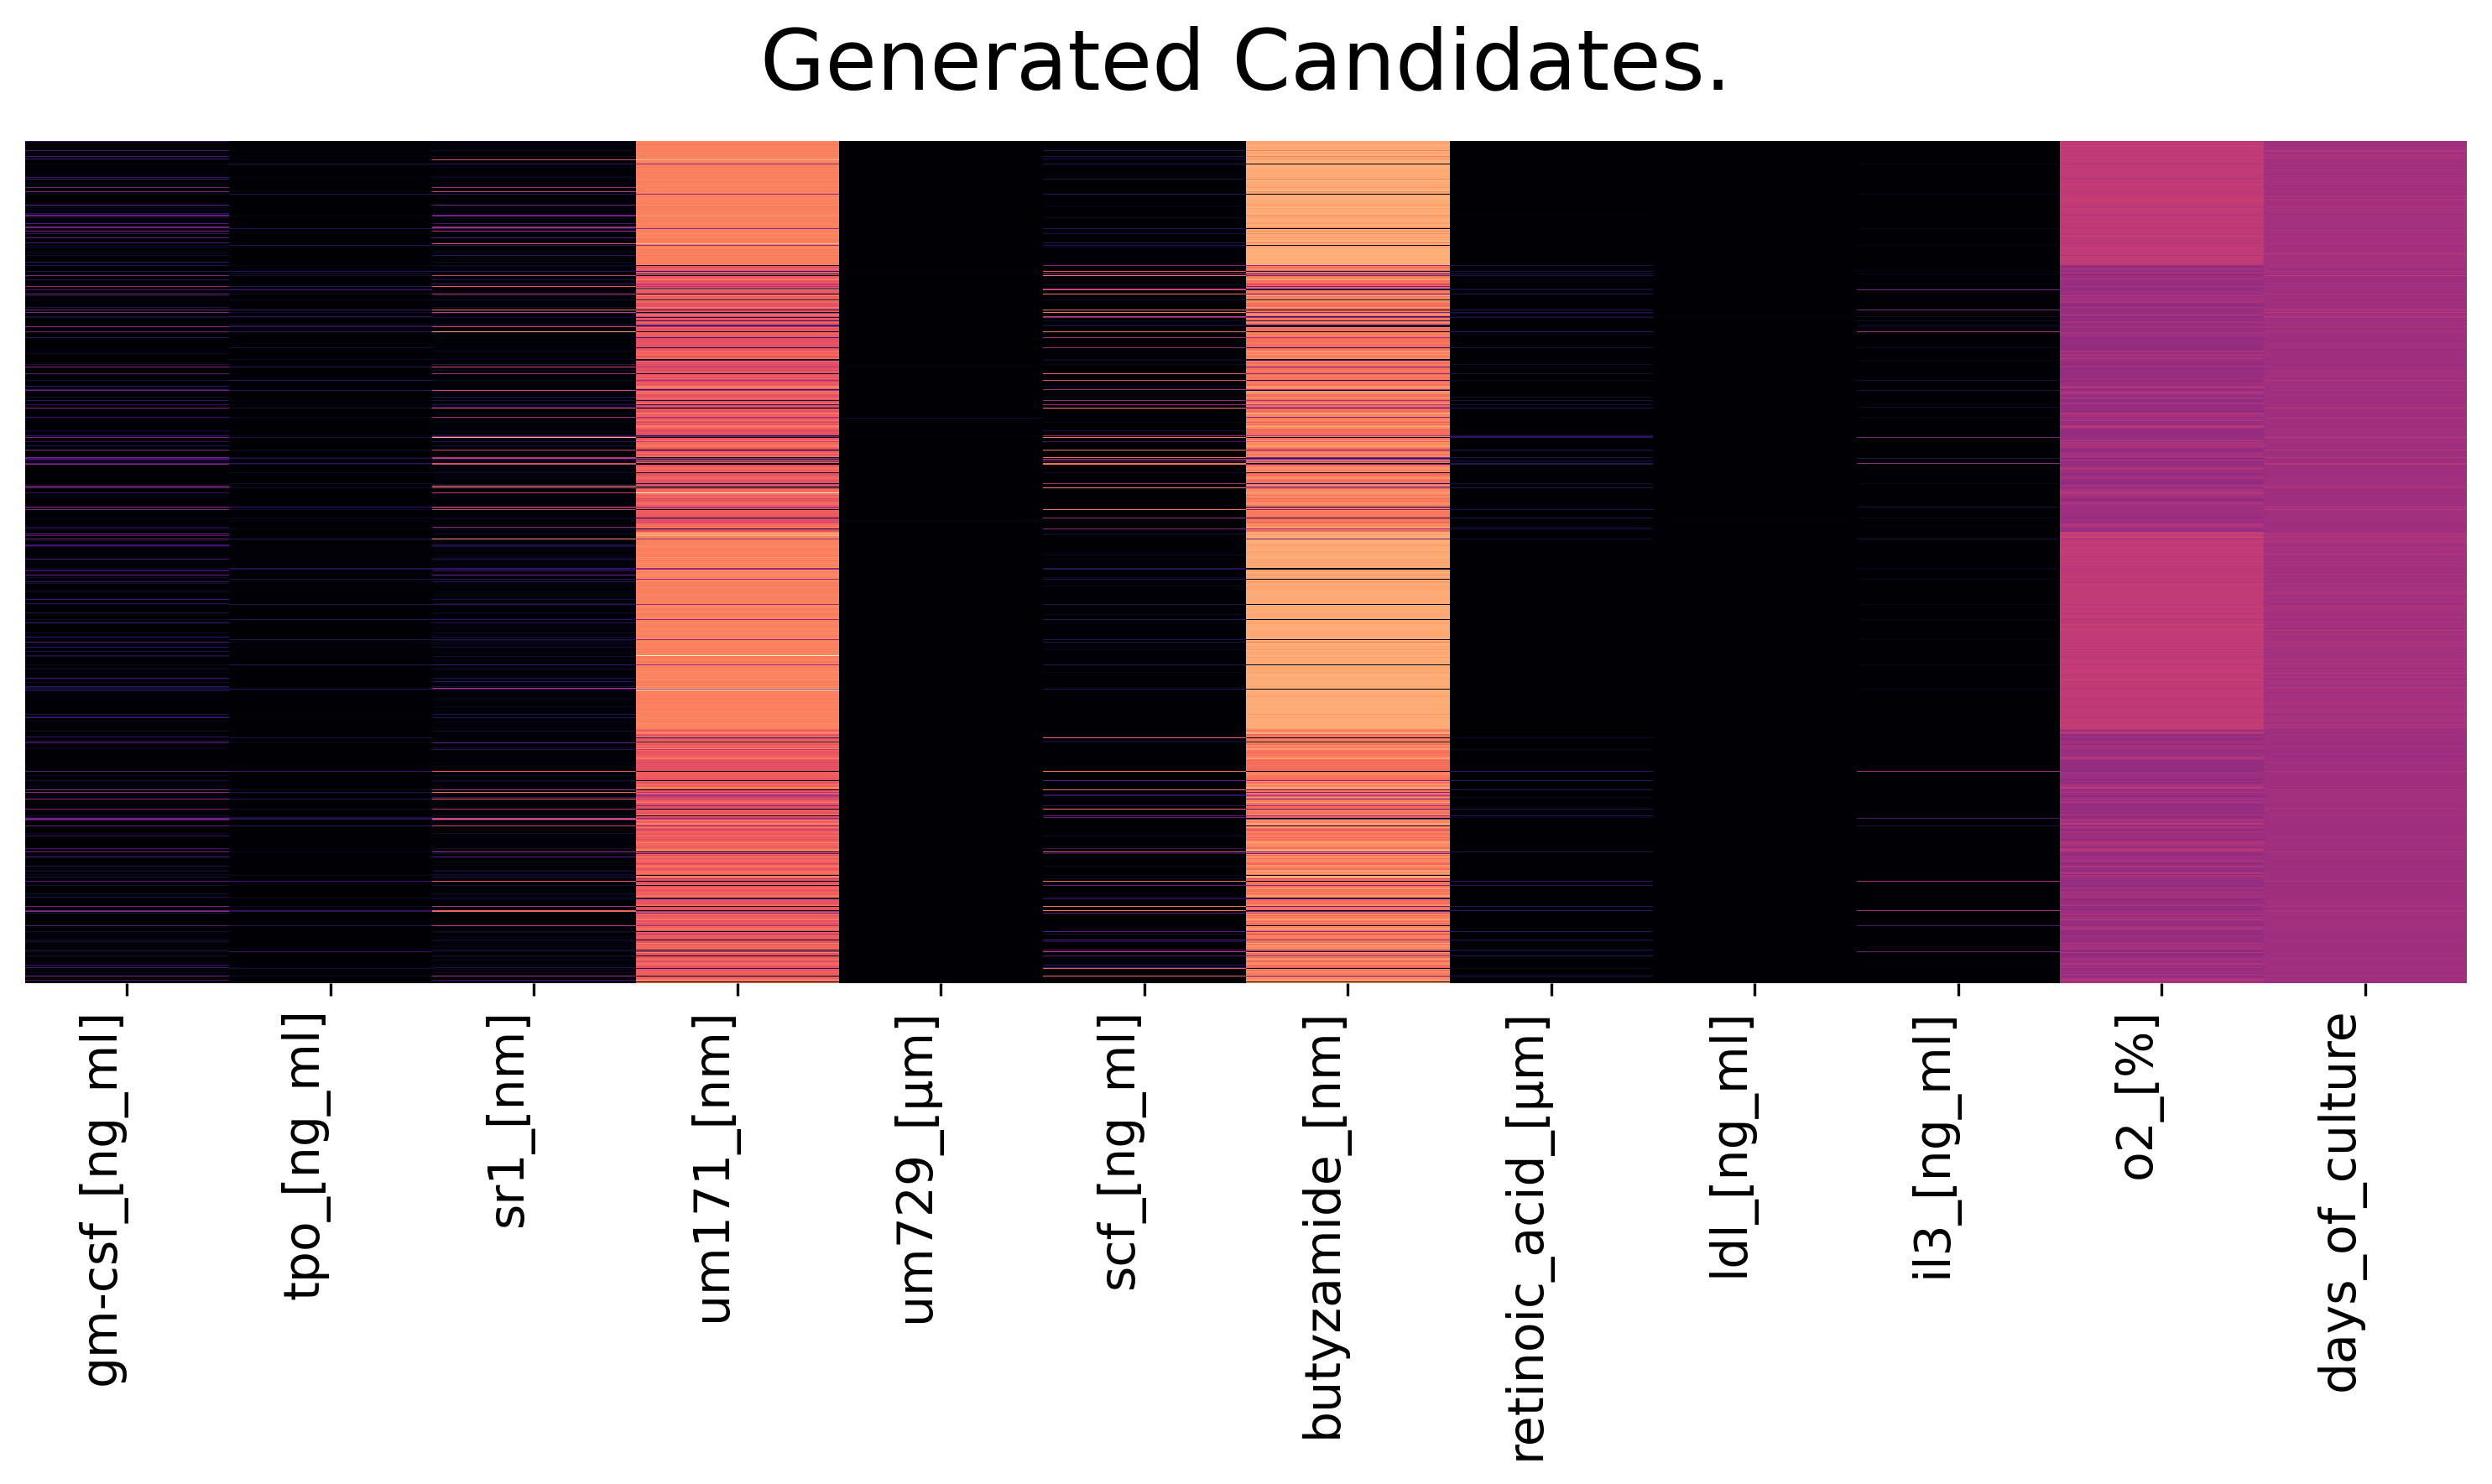

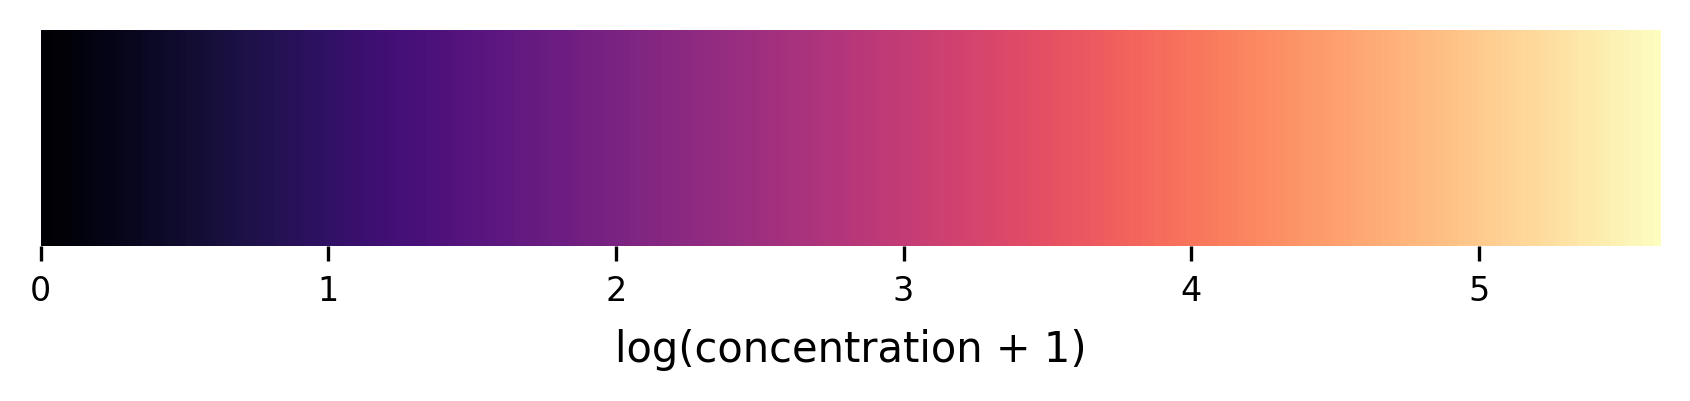

In [26]:
# --- Your existing heatmap code (slightly adjusted) ---
filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
mgk_enriching_mask = (filtered_candidates_df_new["late_MgkPro_prop"] > 0.15)
filtered_candidates_df_new = filtered_candidates_df_new[mgk_enriching_mask]

filtered_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1))

# Compute min/max for consistent colorbar range (optional)
vmin = filtered_concs.min().min()
vmax = filtered_concs.max().max()

# Create the main heatmap (but we won't save its colorbar)
plt.figure(figsize=(10, 6), dpi=300)
ax = sns.heatmap(
    filtered_concs,
    annot=False,
    fmt='.2f',
    linewidths=0.00,
    linecolor='black',
    cmap="magma",
    cbar=False,                     # disable the default colorbar
    vmin=vmin, vmax=vmax            # keep consistent range
)
ax.set_yticklabels([])
ax.tick_params(axis='y', left=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=14)
plt.title('Generated Candidates.', fontsize=24, pad=15)
plt.tight_layout()
plt.savefig('../plots/filtered_concentrations_heatmap_new_data.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Create a separate, standalone colorbar (fat and short) ---
fig_cbar = plt.figure(figsize=(6, 1.2), dpi=300)   # wide figure, short height → "fat and short"
ax_cbar = fig_cbar.add_axes([0.05, 0.2, 0.9, 0.6])  # [left, bottom, width, height] – adjust as needed

# Create a ScalarMappable with the same colormap and normalization
norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='magma')   # use the same colormap as in heatmap
sm.set_array([])

# Draw the colorbar horizontally
cbar = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)
cbar.ax.tick_params(labelsize=8)

# Remove any extra spines or decorations
ax_cbar.set_frame_on(False)

# Save the standalone colorbar
fig_cbar.savefig('../plots/heatmap_colorbar_separate_new_data.png', bbox_inches='tight', dpi=300)
plt.show()


## Panel F: Comparison Before/After Having Seen Sakurai.

### Plot Histograms of CT Proportions Overlaid.

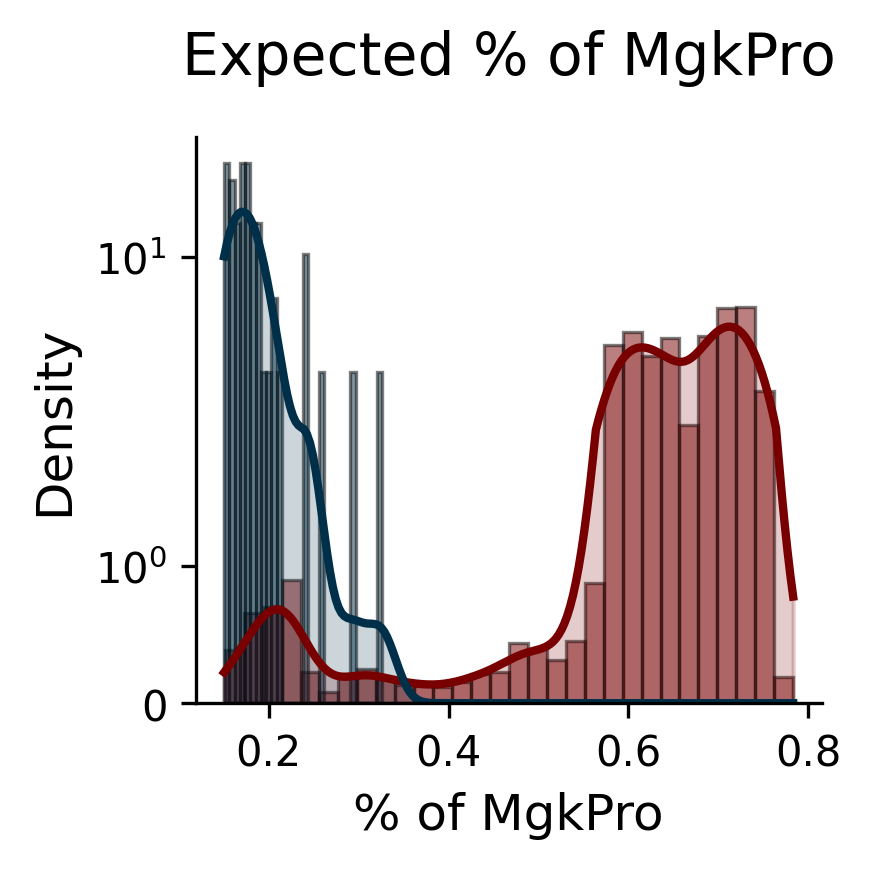

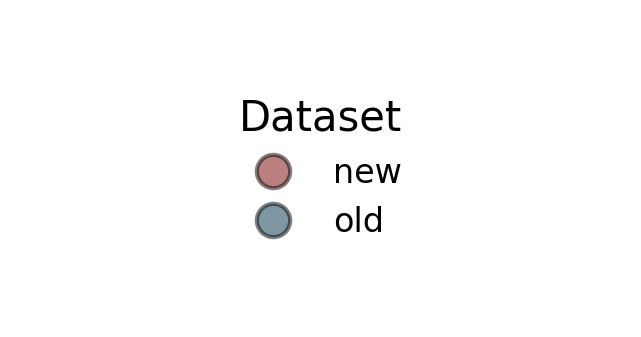

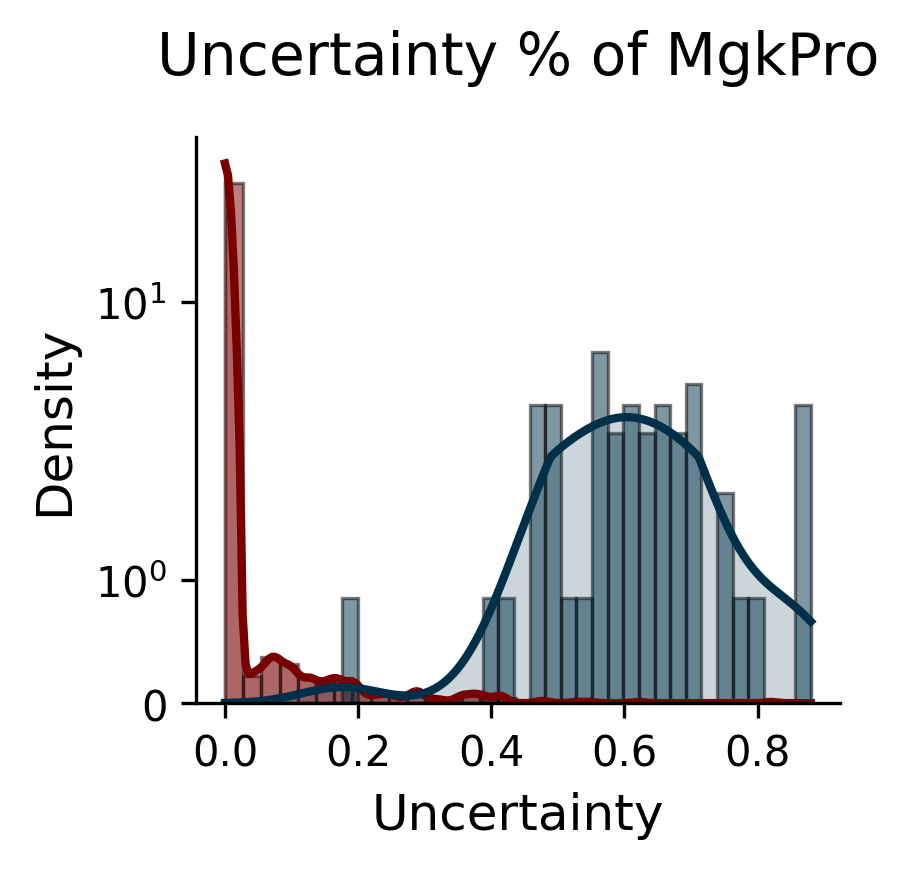

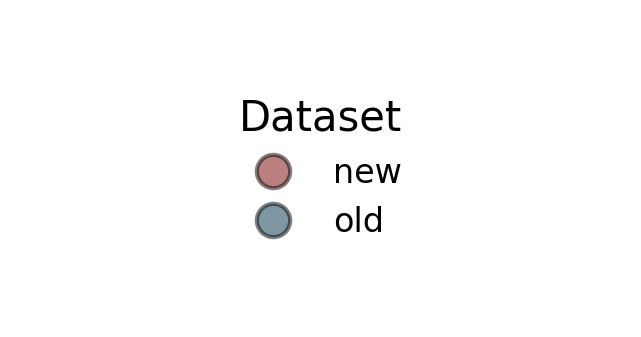

In [27]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']
cols_list = ['late_MgkPro_prop', 'target_ct_loss_std']

col2xaxis_label = {
    "late_MgkPro_prop":  r"% of MgkPro",
    "target_ct_loss_std": "Uncertainty"
}

col2suptitle = {
    "late_MgkPro_prop":  r"Expected % of MgkPro",
    "target_ct_loss_std": r"Uncertainty % of MgkPro"
}

for col in cols_list:
    # Data
    filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
    mgk_enriching_mask = (filtered_candidates_df["late_MgkPro_prop"] > 0.15)
    filtered_candidates_df = filtered_candidates_df[mgk_enriching_mask]

    filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
    mgk_enriching_mask = (filtered_candidates_df_new["late_MgkPro_prop"] > 0.15)
    filtered_candidates_df_new = filtered_candidates_df_new[mgk_enriching_mask]

    data_new = filtered_candidates_df_new[col].dropna()
    data_old = filtered_candidates_df[col].dropna()

    # Density histograms
    bins = 30
    hist_new, bin_edges_new = np.histogram(data_new, bins=bins, density=True)
    hist_old, bin_edges_old = np.histogram(data_old, bins=bins, density=True)

    bin_centers_new = (bin_edges_new[:-1] + bin_edges_new[1:]) / 2
    bin_centers_old = (bin_edges_old[:-1] + bin_edges_old[1:]) / 2
    bin_width_new = np.diff(bin_edges_new)[0]
    bin_width_old = np.diff(bin_edges_old)[0]

    # Main plot
    plt.figure(figsize=(3, 3), dpi=300)
    plt.bar(bin_centers_new, hist_new, width=bin_width_new,
            color=palette[0], alpha=0.5, edgecolor='black', linewidth=0.8,
            label='new', align='center')
    plt.bar(bin_centers_old, hist_old, width=bin_width_old,
            color=palette[3], alpha=0.5, edgecolor='black', linewidth=0.8,
            label='old', align='center')

    # KDE
    kde_new = stats.gaussian_kde(data_new)
    kde_old = stats.gaussian_kde(data_old)
    x_grid = np.linspace(min(data_new.min(), data_old.min()),
                         max(data_new.max(), data_old.max()), 200)

    plt.plot(x_grid, kde_new(x_grid), color=palette[0], linewidth=2, label='_nolegend_')
    plt.plot(x_grid, kde_old(x_grid), color=palette[3], linewidth=2, label='_nolegend_')
    plt.fill_between(x_grid, kde_new(x_grid), color=palette[0], alpha=0.2)
    plt.fill_between(x_grid, kde_old(x_grid), color=palette[3], alpha=0.2)

    # Labels, title, and log scale
    xlabel = col2xaxis_label[col]
    title = col2suptitle[col]
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.yscale("symlog")
    plt.title(title, fontsize=14, pad=15)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'../plots/enrichment_unfiltered_{col}_histogram_with_kde.png', bbox_inches='tight', dpi=300)
    plt.show()

    # ------------------------------------------------------------------
    # Save legend separately using circles (dots) instead of patches
    # ------------------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=palette[0],
               markeredgecolor='black', markersize=8, label='new', alpha=0.5),
        Line2D([0], [0], marker='o', color='none', markerfacecolor=palette[3],
               markeredgecolor='black', markersize=8, label='old', alpha=0.5)
    ]

    fig_legend = plt.figure(figsize=(2.5, 1.2), dpi=300)
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')
    ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                     fontsize=8, loc='center', frameon=False)
    fig_legend.savefig(f'../plots/{col}_legend_separate.png', bbox_inches='tight', dpi=300)
    plt.show()


### Same as above with updated color.s

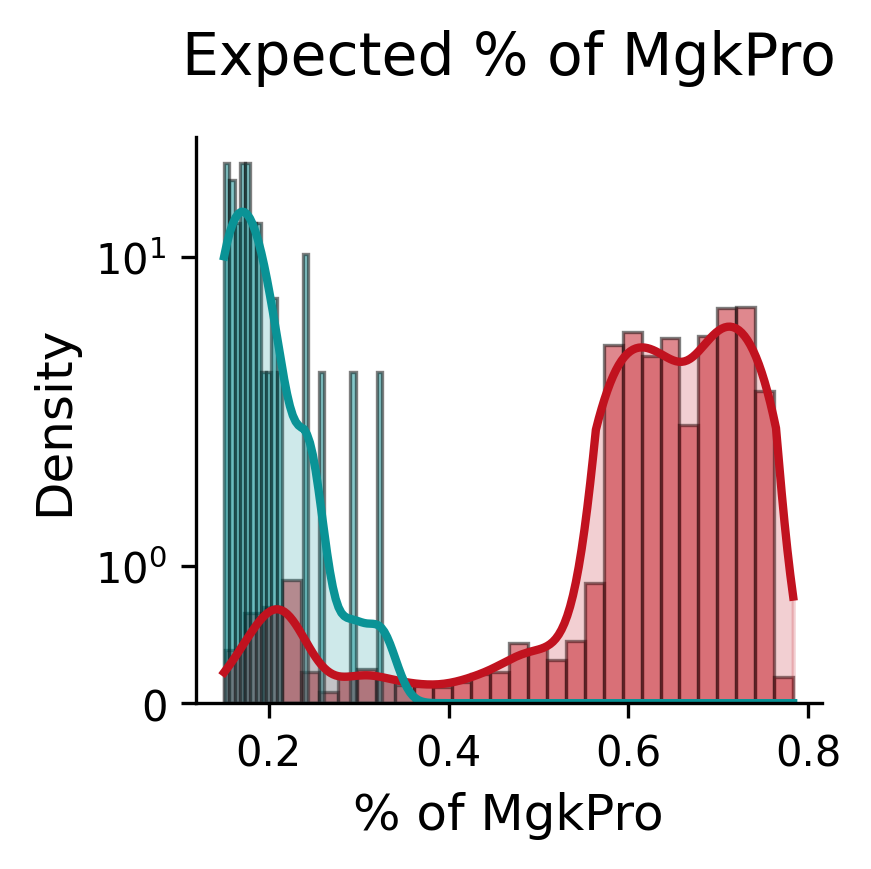

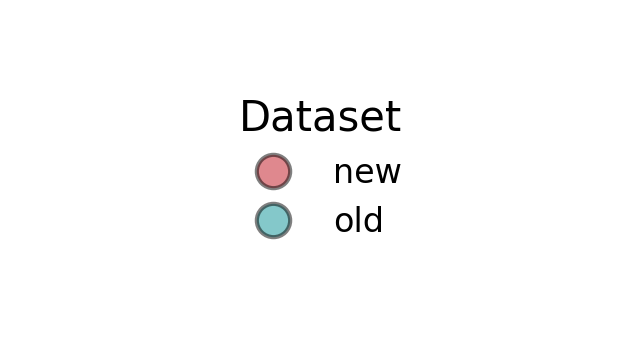

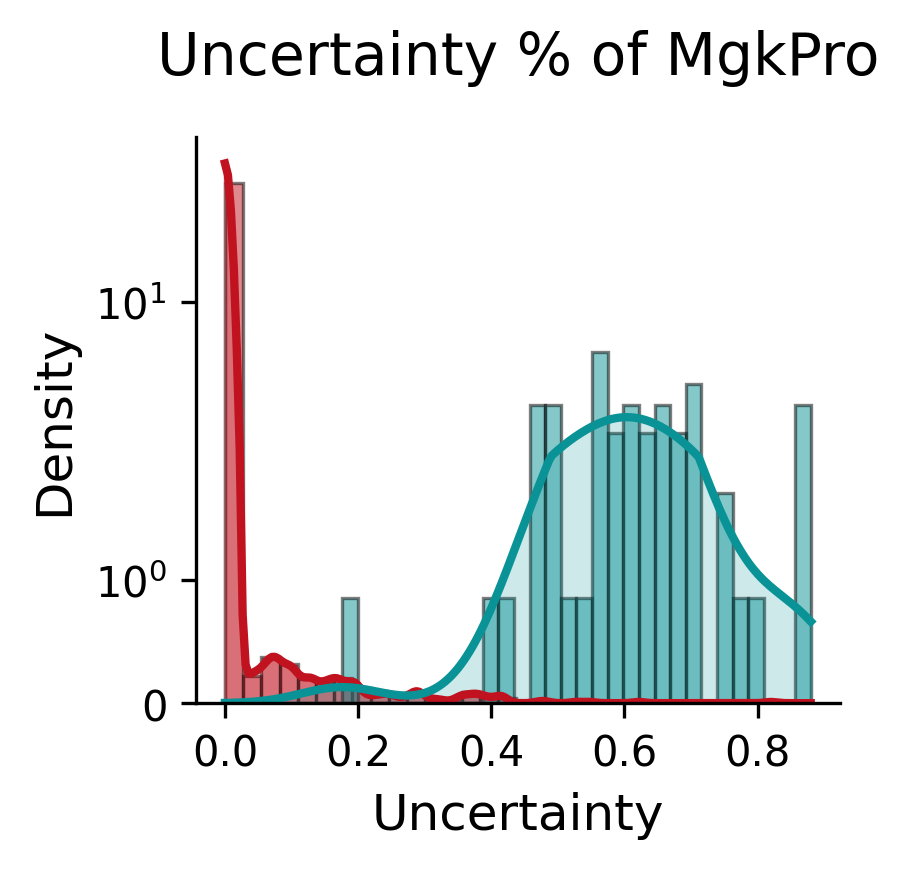

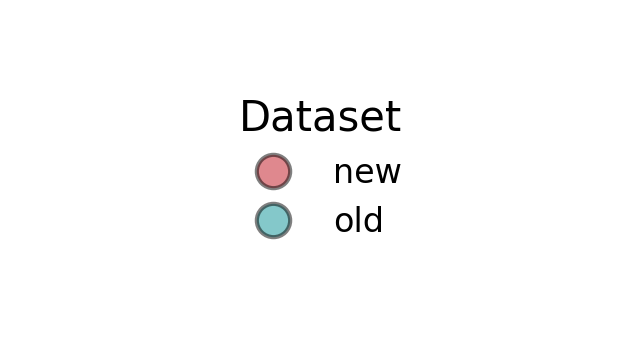

In [52]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import scipy.stats as stats
import seaborn as sns

# Colorblind‑friendly palette (matching PCA plots)
# new_color = '#D55E00'   # orange for new candidates
# old_color = '#0072B2'   # blue for old candidates

# old_color = '#003049'   # dark navy blue (old candidates)
old_color = "#0a9396"
new_color = '#c1121f'   # crimson (new candidates)
real_color = '#888888'  # gray (for background points – not used here)

cols_list = ['late_MgkPro_prop', 'target_ct_loss_std']

col2xaxis_label = {
    "late_MgkPro_prop":  r"% of MgkPro",
    "target_ct_loss_std": "Uncertainty"
}

col2suptitle = {
    "late_MgkPro_prop":  r"Expected % of MgkPro",
    "target_ct_loss_std": r"Uncertainty % of MgkPro"
}

for col in cols_list:
    # Data
    filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
    mgk_enriching_mask = (filtered_candidates_df["late_MgkPro_prop"] > 0.15)
    filtered_candidates_df = filtered_candidates_df[mgk_enriching_mask]

    filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
    mgk_enriching_mask = (filtered_candidates_df_new["late_MgkPro_prop"] > 0.15)
    filtered_candidates_df_new = filtered_candidates_df_new[mgk_enriching_mask]

    data_new = filtered_candidates_df_new[col].dropna()
    data_old = filtered_candidates_df[col].dropna()

    # Density histograms
    bins = 30
    hist_new, bin_edges_new = np.histogram(data_new, bins=bins, density=True)
    hist_old, bin_edges_old = np.histogram(data_old, bins=bins, density=True)

    bin_centers_new = (bin_edges_new[:-1] + bin_edges_new[1:]) / 2
    bin_centers_old = (bin_edges_old[:-1] + bin_edges_old[1:]) / 2
    bin_width_new = np.diff(bin_edges_new)[0]
    bin_width_old = np.diff(bin_edges_old)[0]

    # Main plot
    plt.figure(figsize=(3, 3), dpi=300)

    # Bars: new in orange, old in blue
    plt.bar(bin_centers_new, hist_new, width=bin_width_new,
            color=new_color, alpha=0.5, edgecolor='black', linewidth=0.8,
            label='new', align='center')
    plt.bar(bin_centers_old, hist_old, width=bin_width_old,
            color=old_color, alpha=0.5, edgecolor='black', linewidth=0.8,
            label='old', align='center')

    # KDE lines and fills
    kde_new = stats.gaussian_kde(data_new)
    kde_old = stats.gaussian_kde(data_old)
    x_grid = np.linspace(min(data_new.min(), data_old.min()),
                         max(data_new.max(), data_old.max()), 200)

    plt.plot(x_grid, kde_new(x_grid), color=new_color, linewidth=2, label='_nolegend_')
    plt.plot(x_grid, kde_old(x_grid), color=old_color, linewidth=2, label='_nolegend_')
    plt.fill_between(x_grid, kde_new(x_grid), color=new_color, alpha=0.2)
    plt.fill_between(x_grid, kde_old(x_grid), color=old_color, alpha=0.2)

    # Labels, title, and log scale
    xlabel = col2xaxis_label[col]
    title = col2suptitle[col]
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.yscale("symlog")
    plt.title(title, fontsize=14, pad=15)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'../plots/enrichment_unfiltered_{col}_histogram_with_kde.png', bbox_inches='tight', dpi=300)
    plt.show()

    # ------------------------------------------------------------------
    # Save legend separately (circles matching new/old colors)
    # ------------------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=new_color,
               markeredgecolor='black', markersize=8, label='new', alpha=0.5),
        Line2D([0], [0], marker='o', color='none', markerfacecolor=old_color,
               markeredgecolor='black', markersize=8, label='old', alpha=0.5)
    ]

    fig_legend = plt.figure(figsize=(2.5, 1.2), dpi=300)
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')
    ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                     fontsize=8, loc='center', frameon=False)
    fig_legend.savefig(f'../plots/{col}_legend_separate.png', bbox_inches='tight', dpi=300)
    plt.show()

### Scatter Plot Performance v Uncertainty.

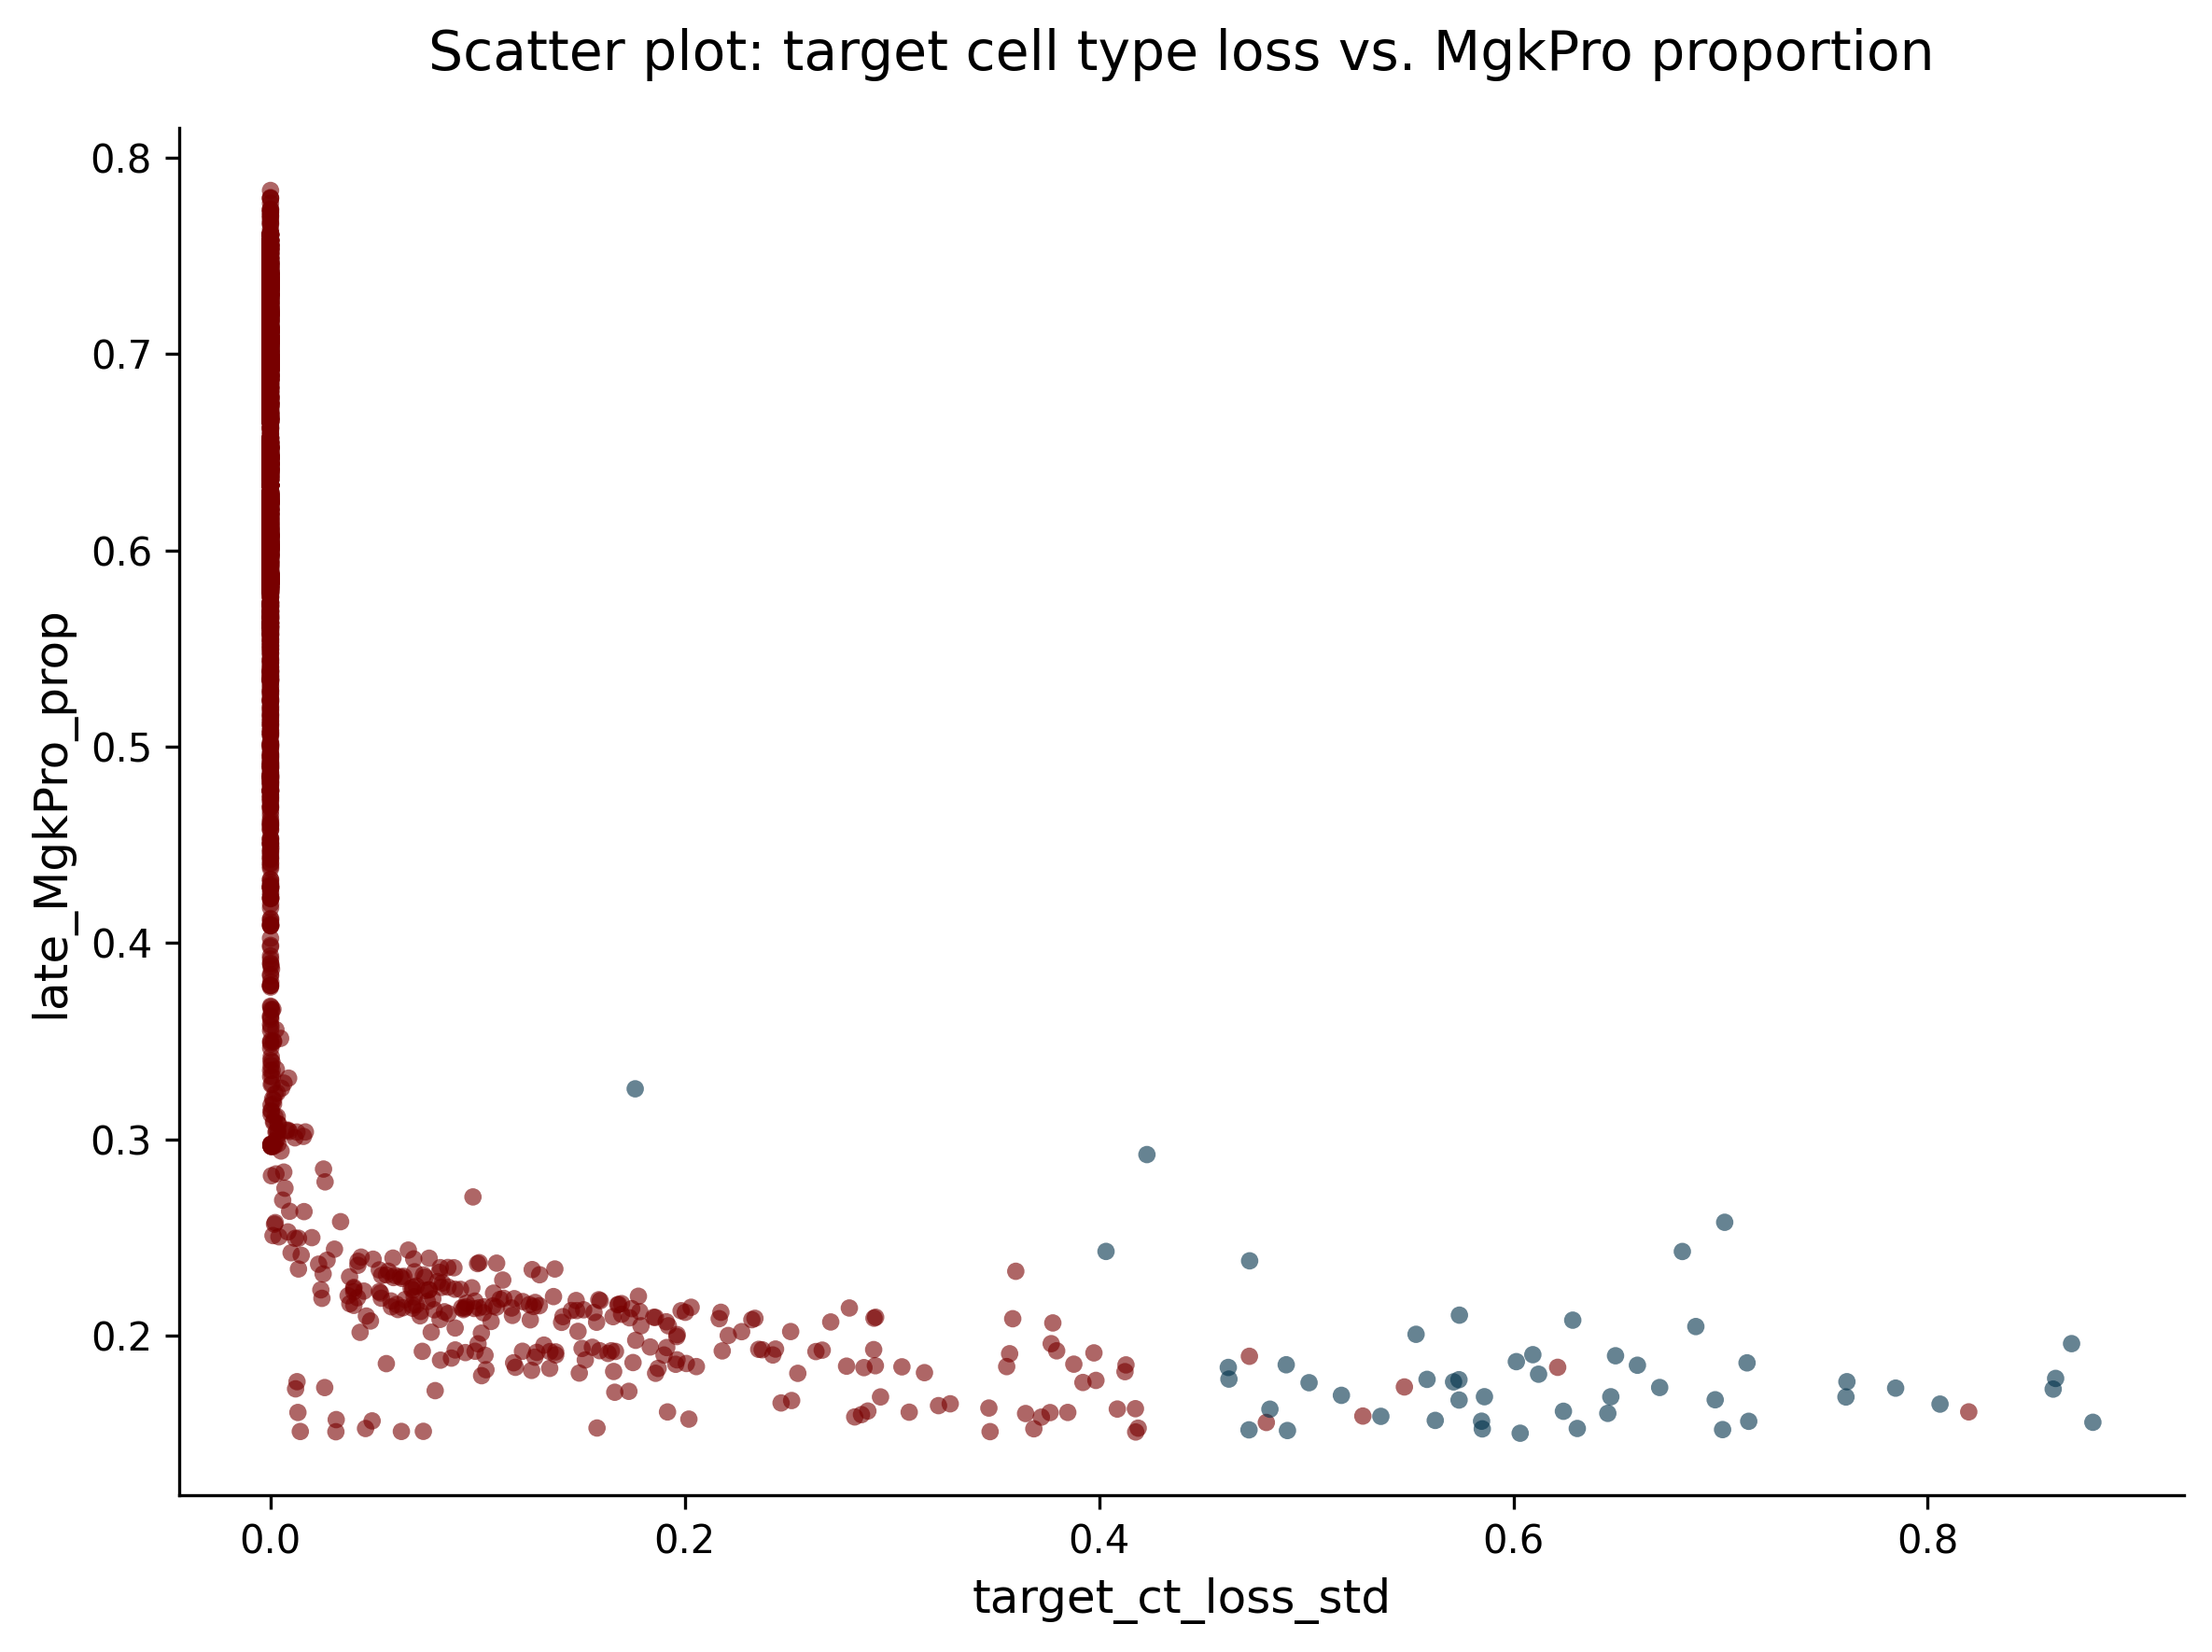

/tmp/ipykernel_3076356/2646320111.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_map['new'], alpha=0.6, label='new', edgecolor='none'),
/tmp/ipykernel_3076356/2646320111.py:51: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_map['old'], alpha=0.6, label='old', edgecolor='none')


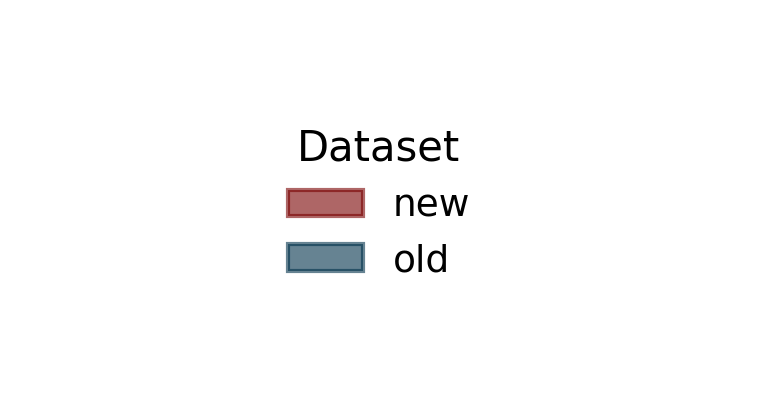

In [28]:
# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# Prepare the two datasets with a common label column
data_new = filtered_candidates_df_new.copy()
data_new['dataset'] = 'new'
data_old = filtered_candidates_df.copy()
data_old['dataset'] = 'old'

# Combine into one DataFrame
combined = pd.concat([data_new, data_old], ignore_index=True)

# Extract columns (drop any rows with missing values)
x_col = 'target_ct_loss_std'
y_col = 'late_MgkPro_prop'
plot_df = combined[[x_col, y_col, 'dataset']].dropna()

# Define color mapping
color_map = {'new': palette[0], 'old': palette[3]}

# ------------------------------------------------------------
# 1. Main scatter plot (NO legend)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=300)

# Plot each dataset separately to control colors without legend
for dataset, color in color_map.items():
    subset = plot_df[plot_df['dataset'] == dataset]
    plt.scatter(subset[x_col], subset[y_col],
                c=color, alpha=0.6, s=20, edgecolor='none',
                label=dataset)          # label assigned but legend=False later

# Remove legend if automatically added (though we didn't call legend, but to be safe)
plt.legend().remove()   # ensures no legend appears

# Labels and title
plt.xlabel('target_ct_loss_std', fontsize=12)
plt.ylabel('late_MgkPro_prop', fontsize=12)
plt.title('Scatter plot: target cell type loss vs. MgkPro proportion', fontsize=14, pad=15)

sns.despine()
plt.tight_layout()
plt.savefig('../plots/scatter_target_ct_loss_std_vs_MgkPro_prop.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Save the legend separately (explicit colored patches)
# ------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=color_map['new'], alpha=0.6, label='new', edgecolor='none'),
    mpatches.Patch(color=color_map['old'], alpha=0.6, label='old', edgecolor='none')
]

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(3, 1.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                 fontsize=9, loc='center', frameon=False)
fig_legend.savefig('../plots/scatter_legend_separate.png', bbox_inches='tight', dpi=300)
plt.show()


### Plot Conditions in PCA Space.

In [ ]:

# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# ----------------------------------------------------------------------
# 1. Prepare real condition vectors (one per experiment)
# ----------------------------------------------------------------------
real_conds = adata_full.obs[protocol_cols].astype(float).values
exp_nums = adata_full.obs["experiment_number"].values

unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)
real_matrix = np.log1p(real_matrix)          # log(1 + concentration)
exp_labels = np.array(exp_labels)

# ----------------------------------------------------------------------
# 2. Prepare candidate condition vectors (old and new)
# ----------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
filtered_candidates_df = filtered_candidates_df[filtered_candidates_df["late_MgkPro_prop"] > 0.15]
old_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1)).values

filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
filtered_candidates_df_new = filtered_candidates_df_new[filtered_candidates_df_new["late_MgkPro_prop"] > 0.15]
new_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1)).values

# ----------------------------------------------------------------------
# Helper function to plot (single panel + two panels) given PCA projections
# ----------------------------------------------------------------------
def plot_pca_projections(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    """Creates single-panel and two-panel scatter plots, saves them and a separate legend."""
    
    # ---- Single panel ----
    plt.figure(figsize=(8, 6), dpi=300)
    plt.scatter(real_pca[:, 0], real_pca[:, 1],
                c='#888888', alpha=0.6, s=30, edgecolor='none')
    plt.scatter(old_pca[:, 0], old_pca[:, 1],
                c=palette[3], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    plt.scatter(new_pca[:, 0], new_pca[:, 1],
                c=palette[0], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        plt.scatter(star_coords[0], star_coords[1],
                    marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    plt.xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title(f'PCA ({method_name})', fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_single.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
    # Left: real + old
    ax_left.scatter(real_pca[:, 0], real_pca[:, 1],
                    c='#888888', alpha=0.6, s=30, edgecolor='none')
    ax_left.scatter(old_pca[:, 0], old_pca[:, 1],
                    c=palette[3], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_left.scatter(star_coords[0], star_coords[1],
                        marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    ax_left.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_left.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_left.set_title(f'Old candidates ({method_name})', fontsize=12)
    # Right: real + new
    ax_right.scatter(real_pca[:, 0], real_pca[:, 1],
                     c='#888888', alpha=0.6, s=30, edgecolor='none')
    ax_right.scatter(new_pca[:, 0], new_pca[:, 1],
                     c=palette[0], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_right.scatter(star_coords[0], star_coords[1],
                         marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    ax_right.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_right.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_right.set_title(f'New candidates ({method_name})', fontsize=12)
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_twopanel.png', dpi=300, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------------
# 3. Find coordinates of experiment 210 (we need real_pca for both methods later)
#    We'll compute star_coords after PCA for each method.
# ----------------------------------------------------------------------
# Helper to get star_coords given real_pca and exp_labels
def get_star_coords(real_pca, exp_labels):
    if 210 in exp_labels:
        idx = np.where(exp_labels == 210)[0][0]
        return real_pca[idx]
    return None

# ----------------------------------------------------------------------
# Approach A: Joint PCA (fit on all data)
# ----------------------------------------------------------------------
all_data = np.vstack([real_matrix, old_concs, new_concs])
pca_joint = PCA(n_components=2)
all_pca_joint = pca_joint.fit_transform(all_data)

n_real = real_matrix.shape[0]
n_old = old_concs.shape[0]
real_pca_joint = all_pca_joint[:n_real]
old_pca_joint = all_pca_joint[n_real:n_real+n_old]
new_pca_joint = all_pca_joint[n_real+n_old:]

star_coords_joint = get_star_coords(real_pca_joint, exp_labels)

plot_pca_projections(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

# ----------------------------------------------------------------------
# Approach B: PCA fit only on real data, then transform candidates
# ----------------------------------------------------------------------
pca_realonly = PCA(n_components=2)
real_pca_realonly = pca_realonly.fit_transform(real_matrix)          # shape (n_real,2)
old_pca_realonly = pca_realonly.transform(old_concs)                 # project old
new_pca_realonly = pca_realonly.transform(new_concs)                 # project new
star_coords_realonly = get_star_coords(real_pca_realonly, exp_labels)

plot_pca_projections(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

# ----------------------------------------------------------------------
# 4. Save the legend separately (same for both methods)
# ----------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='lightgrey', alpha=0.6, label='Real experiments', edgecolor='none'),
    mpatches.Patch(color=palette[3], alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color=palette[0], alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color='gold', label='Exp 210', edgecolor='black', linewidth=1)
]
fig_legend = plt.figure(figsize=(4, 2.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset / Condition',
                 title_fontsize=10, fontsize=9, loc='center', frameon=False)
fig_legend.savefig('../plots/pca_legend_separate.png', bbox_inches='tight', dpi=300)
plt.close(fig_legend)

print("All plots saved:")
print("  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png")
print("  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png")
print("  - Legend: output/pca_legend_separate.png")

KeyboardInterrupt: 

### Scatter PLot pCa with new colors

In [47]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Your original palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# ----------------------------------------------------------------------
# Helper: lighten a hex color (mix with white)
# ----------------------------------------------------------------------
def lighten_color(hex_color, factor=0.6):
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (1, 3, 5)])
    light_rgb = rgb + (255 - rgb) * factor
    light_rgb = np.clip(light_rgb, 0, 255).astype(int)
    return f'#{light_rgb[0]:02x}{light_rgb[1]:02x}{light_rgb[2]:02x}'

# Lightened colours for scatter points (more distinguishable)
light_old = lighten_color(palette[3], 0.5)   # lighter blue
light_new = lighten_color(palette[0], 0.5)   # lighter red/burgundy
real_color = '#888888'                        # medium gray

# ----------------------------------------------------------------------
# 1. Prepare real condition vectors (one per experiment)
# ----------------------------------------------------------------------
real_conds = adata_full.obs[protocol_cols].astype(float).values
exp_nums = adata_full.obs["experiment_number"].values

unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)
real_matrix = np.log1p(real_matrix)          # log(1 + concentration)
exp_labels = np.array(exp_labels)

# ----------------------------------------------------------------------
# 2. Prepare candidate condition vectors (old and new)
# ----------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
filtered_candidates_df = filtered_candidates_df[filtered_candidates_df["late_MgkPro_prop"] > 0.15]
old_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1)).values

filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
filtered_candidates_df_new = filtered_candidates_df_new[filtered_candidates_df_new["late_MgkPro_prop"] > 0.15]
new_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1)).values

# ----------------------------------------------------------------------
# Helper function to plot (single panel + two panels) using SCATTER with light colors
# ----------------------------------------------------------------------
def plot_pca_projections(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    """Creates single-panel and two-panel scatter plots with distinguishable colors."""
    
    # ---- Single panel ----
    plt.figure(figsize=(8, 6), dpi=300)
    plt.scatter(real_pca[:, 0], real_pca[:, 1],
                c=real_color, alpha=0.6, s=30, edgecolor='none')
    plt.scatter(old_pca[:, 0], old_pca[:, 1],
                c=light_old, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    plt.scatter(new_pca[:, 0], new_pca[:, 1],
                c=light_new, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        plt.scatter(star_coords[0], star_coords[1],
                    marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    plt.xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title(f'PCA ({method_name})', fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_single.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
    # Left: real + old
    ax_left.scatter(real_pca[:, 0], real_pca[:, 1],
                    c=real_color, alpha=0.6, s=30, edgecolor='none')
    ax_left.scatter(old_pca[:, 0], old_pca[:, 1],
                    c=light_old, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_left.scatter(star_coords[0], star_coords[1],
                        marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    ax_left.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_left.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_left.set_title(f'Old candidates ({method_name})', fontsize=12)
    # Right: real + new
    ax_right.scatter(real_pca[:, 0], real_pca[:, 1],
                     c=real_color, alpha=0.6, s=30, edgecolor='none')
    ax_right.scatter(new_pca[:, 0], new_pca[:, 1],
                     c=light_new, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_right.scatter(star_coords[0], star_coords[1],
                         marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    ax_right.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_right.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_right.set_title(f'New candidates ({method_name})', fontsize=12)
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_twopanel.png', dpi=300, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------------
# 3. Find coordinates of experiment 210
# ----------------------------------------------------------------------
def get_star_coords(real_pca, exp_labels):
    if 210 in exp_labels:
        idx = np.where(exp_labels == 210)[0][0]
        return real_pca[idx]
    return None

# ----------------------------------------------------------------------
# Approach A: Joint PCA (fit on all data)
# ----------------------------------------------------------------------
all_data = np.vstack([real_matrix, old_concs, new_concs])
pca_joint = PCA(n_components=2)
all_pca_joint = pca_joint.fit_transform(all_data)

n_real = real_matrix.shape[0]
n_old = old_concs.shape[0]
real_pca_joint = all_pca_joint[:n_real]
old_pca_joint = all_pca_joint[n_real:n_real+n_old]
new_pca_joint = all_pca_joint[n_real+n_old:]

star_coords_joint = get_star_coords(real_pca_joint, exp_labels)

plot_pca_projections(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

# ----------------------------------------------------------------------
# Approach B: PCA fit only on real data, then transform candidates
# ----------------------------------------------------------------------
pca_realonly = PCA(n_components=2)
real_pca_realonly = pca_realonly.fit_transform(real_matrix)
old_pca_realonly = pca_realonly.transform(old_concs)
new_pca_realonly = pca_realonly.transform(new_concs)
star_coords_realonly = get_star_coords(real_pca_realonly, exp_labels)

plot_pca_projections(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

# ----------------------------------------------------------------------
# 4. Save the legend separately (using lightened colors)
# ----------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=real_color, alpha=0.6, label='Real experiments', edgecolor='none'),
    mpatches.Patch(color=light_old, alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color=light_new, alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color='gold', label='Exp 210', edgecolor='black', linewidth=1)
]
fig_legend = plt.figure(figsize=(4, 2.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset / Condition',
                 title_fontsize=10, fontsize=9, loc='center', frameon=False)
fig_legend.savefig('../plots/pca_legend_separate.png', bbox_inches='tight', dpi=300)
plt.close(fig_legend)

print("All plots saved:")
print("  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png")
print("  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png")
print("  - Legend: output/pca_legend_separate.png")

All plots saved:
  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png
  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png
  - Legend: output/pca_legend_separate.png


/tmp/ipykernel_3076356/2391692596.py:152: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=real_color, alpha=0.6, label='Real experiments', edgecolor='none'),
/tmp/ipykernel_3076356/2391692596.py:153: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=light_old, alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
/tmp/ipykernel_3076356/2391692596.py:154: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=light_new, alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
/tmp/ipykernel_3076356/2391692596.py:155: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='gold', label='Exp 210', edgecolor='black', linewidth=1)


### Scatter with new colors.

In [54]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# =============================================================================
# COLORBLIND-FRIENDLY PALETTE (blue / orange / gray / yellow)
# =============================================================================
real_color = '#888888'      # gray for real experiments
old_color  = '#0072B2'      # blue for old candidates
new_color  = '#D55E00'      # orange for new candidates
star_color = 'gold'         # yellow star with black edge


# old_color = '#003049'   # dark navy blue (old candidates)
old_color = "#0a9396"
new_color = '#c1121f'   # crimson (new candidates)
real_color = '#888888'  # gray (for background points – not used here)

# =============================================================================
# 1. Prepare real condition vectors (one per experiment)
# =============================================================================
real_conds = adata_full.obs[protocol_cols].astype(float).values
exp_nums = adata_full.obs["experiment_number"].values

unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)
real_matrix = np.log1p(real_matrix)          # log(1 + concentration)
exp_labels = np.array(exp_labels)

# =============================================================================
# 2. Prepare candidate condition vectors (old and new)
# =============================================================================
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
filtered_candidates_df = filtered_candidates_df[filtered_candidates_df["late_MgkPro_prop"] > 0.15]
old_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1)).values

filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
filtered_candidates_df_new = filtered_candidates_df_new[filtered_candidates_df_new["late_MgkPro_prop"] > 0.15]
new_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1)).values

# =============================================================================
# Helper: get coordinates of experiment 210 (star point)
# =============================================================================
def get_star_coords(real_pca, exp_labels):
    if 210 in exp_labels:
        idx = np.where(exp_labels == 210)[0][0]
        return real_pca[idx]
    return None

# =============================================================================
# Plotting function: single panel and two panels (NO legend on main plots)
# =============================================================================
def plot_pca_projections(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    """Creates single-panel and two-panel scatter plots; saves figures and separate legend."""
    
    # ---- Single panel (all groups together) ----
    plt.figure(figsize=(8, 6), dpi=300)
    plt.scatter(real_pca[:, 0], real_pca[:, 1],
                c=real_color, alpha=0.6, s=30, edgecolor='none')
    plt.scatter(old_pca[:, 0], old_pca[:, 1],
                c=old_color, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    plt.scatter(new_pca[:, 0], new_pca[:, 1],
                c=new_color, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        plt.scatter(star_coords[0], star_coords[1],
                    marker='*', s=300, c=star_color, edgecolor='black', linewidth=1, zorder=5)
    plt.xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title(f'PCA ({method_name})', fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_single.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels (left: real+old, right: real+new) ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
    
    # Left panel: real + old
    ax_left.scatter(real_pca[:, 0], real_pca[:, 1],
                    c=real_color, alpha=0.6, s=30, edgecolor='none')
    ax_left.scatter(old_pca[:, 0], old_pca[:, 1],
                    c=old_color, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_left.scatter(star_coords[0], star_coords[1],
                        marker='*', s=300, c=star_color, edgecolor='black', linewidth=1, zorder=5)
    ax_left.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_left.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_left.set_title(f'Old candidates ({method_name})', fontsize=12)
    
    # Right panel: real + new
    ax_right.scatter(real_pca[:, 0], real_pca[:, 1],
                     c=real_color, alpha=0.6, s=30, edgecolor='none')
    ax_right.scatter(new_pca[:, 0], new_pca[:, 1],
                     c=new_color, alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_right.scatter(star_coords[0], star_coords[1],
                         marker='*', s=300, c=star_color, edgecolor='black', linewidth=1, zorder=5)
    ax_right.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_right.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_right.set_title(f'New candidates ({method_name})', fontsize=12)
    
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_twopanel.png', dpi=300, bbox_inches='tight')
    plt.close()

# =============================================================================
# Approach A: Joint PCA (fit on all data)
# =============================================================================
all_data = np.vstack([real_matrix, old_concs, new_concs])
pca_joint = PCA(n_components=2)
all_pca_joint = pca_joint.fit_transform(all_data)

n_real = real_matrix.shape[0]
n_old = old_concs.shape[0]
real_pca_joint = all_pca_joint[:n_real]
old_pca_joint = all_pca_joint[n_real:n_real+n_old]
new_pca_joint = all_pca_joint[n_real+n_old:]

star_coords_joint = get_star_coords(real_pca_joint, exp_labels)

plot_pca_projections(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

# =============================================================================
# Approach B: PCA fit only on real data, then transform candidates
# =============================================================================
pca_realonly = PCA(n_components=2)
real_pca_realonly = pca_realonly.fit_transform(real_matrix)
old_pca_realonly = pca_realonly.transform(old_concs)
new_pca_realonly = pca_realonly.transform(new_concs)
star_coords_realonly = get_star_coords(real_pca_realonly, exp_labels)

plot_pca_projections(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

# =============================================================================
# Separate legend (saved once, matches the colours above)
# =============================================================================
legend_handles = [
    mpatches.Patch(color=real_color, alpha=0.6, label='Real experiments', edgecolor='none'),
    mpatches.Patch(color=old_color, alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color=new_color, alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color=star_color, label='Modified Sakurai Medium', edgecolor='black', linewidth=1)
]
fig_legend = plt.figure(figsize=(4, 2.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset / Condition',
                 title_fontsize=10, fontsize=9, loc='center', frameon=False)
fig_legend.savefig('../plots/pca_legend_separate.png', bbox_inches='tight', dpi=300)
plt.close(fig_legend)

print("All plots saved:")
print("  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png")
print("  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png")
print("  - Legend: output/pca_legend_separate.png")


All plots saved:
  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png
  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png
  - Legend: output/pca_legend_separate.png


/tmp/ipykernel_3076356/2693187961.py:152: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=real_color, alpha=0.6, label='Real experiments', edgecolor='none'),
/tmp/ipykernel_3076356/2693187961.py:153: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=old_color, alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
/tmp/ipykernel_3076356/2693187961.py:154: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=new_color, alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
/tmp/ipykernel_3076356/2693187961.py:155: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=star_color, label='Modified Sakurai Medium', edgecolor='black', linewidth=1)


### Plot PCA Legend Separately.

In [55]:
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=real_color,
           markeredgecolor='none', markersize=8, label='Real experiments', alpha=0.6),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=old_color,
           markeredgecolor='black', markersize=8, label='Original', alpha=0.7, markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=new_color,
           markeredgecolor='black', markersize=8, label='Original + Sakurai', alpha=0.7, markeredgewidth=0.5),
    Line2D([0], [0], marker='*', color='gold', markerfacecolor='gold',
           markeredgecolor='black', markersize=12, label='Sakurai Medium', linestyle='none')
]

fig_legend = plt.figure(figsize=(4, 2.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset / Condition',
                 title_fontsize=10, fontsize=9, loc='center', frameon=False)
fig_legend.savefig('../plots/pca_legend_separate.png', bbox_inches='tight', dpi=300)
plt.close(fig_legend)

## PCA as Contour Plots.

In [36]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Your original palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# ----------------------------------------------------------------------
# Helper: lighten a hex color by mixing with white
# ----------------------------------------------------------------------
def lighten_color(hex_color, factor=0.6):
    """Return a lighter version of a hex color."""
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (1, 3, 5)])
    light_rgb = rgb + (255 - rgb) * factor
    light_rgb = np.clip(light_rgb, 0, 255).astype(int)
    return f'#{light_rgb[0]:02x}{light_rgb[1]:02x}{light_rgb[2]:02x}'

# Lighter colours for contours
light_grey = '#d3d3d3'                # very light grey for real experiments
light_old = lighten_color(palette[3], 0.7)   # lightened #003049
light_new = lighten_color(palette[0], 0.7)   # lightened #780000

# ----------------------------------------------------------------------
# Updated plotting function using contours
# ----------------------------------------------------------------------
def plot_pca_projections_contour(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    """Contour plots (single panel + two panels) with lighter colours."""
    
    # ---- Single panel ----
    plt.figure(figsize=(8, 6), dpi=300)
    # Real experiments contour (light grey)
    if len(real_pca) > 1:
        sns.kdeplot(x=real_pca[:, 0], y=real_pca[:, 1],
                    color=light_grey, fill=True, alpha=0.5)
                    # color=light_grey, fill=True, alpha=0.5, levels=4, thresh=0.05)
    # Old candidates contour
    if len(old_pca) > 1:
        sns.kdeplot(x=old_pca[:, 0], y=old_pca[:, 1],
                    color=light_old, fill=True, alpha=0.5)
                    # color=light_old, fill=True, alpha=0.5, levels=4, thresh=0.05)
    # New candidates contour
    if len(new_pca) > 1:
        sns.kdeplot(x=new_pca[:, 0], y=new_pca[:, 1],
                    color=light_new, fill=True, alpha=0.5)
                    # color=light_new, fill=True, alpha=0.5, levels=4, thresh=0.05)
    # Highlight experiment 210 with a star
    if star_coords is not None:
        plt.scatter(star_coords[0], star_coords[1],
                    marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=10)
    plt.xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title(f'PCA ({method_name})', fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_single_contour.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
    # Left panel: real + old contours
    if len(real_pca) > 1:
        sns.kdeplot(x=real_pca[:, 0], y=real_pca[:, 1], ax=ax_left,
                    color=light_grey, fill=True, alpha=0.5)
                    # color=light_grey, fill=True, alpha=0.5, levels=5, thresh=0.05)
    if len(old_pca) > 1:
        sns.kdeplot(x=old_pca[:, 0], y=old_pca[:, 1], ax=ax_left,
                    color=light_old, fill=True, alpha=0.5)
                    # color=light_old, fill=True, alpha=0.5, levels=5, thresh=0.05)
    if star_coords is not None:
        ax_left.scatter(star_coords[0], star_coords[1],
                        marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=10)
    ax_left.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_left.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_left.set_title(f'Old candidates ({method_name})', fontsize=12)
    
    # Right panel: real + new contours
    if len(real_pca) > 1:
        sns.kdeplot(x=real_pca[:, 0], y=real_pca[:, 1], ax=ax_right,
                    color=light_grey, fill=True, alpha=0.5)
                    # color=light_grey, fill=True, alpha=0.5, levels=5, thresh=0.05)
    if len(new_pca) > 1:
        sns.kdeplot(x=new_pca[:, 0], y=new_pca[:, 1], ax=ax_right,
                    color=light_new, fill=True, alpha=0.5)
                    # color=light_new, fill=True, alpha=0.5, levels=5, thresh=0.05)
    if star_coords is not None:
        ax_right.scatter(star_coords[0], star_coords[1],
                         marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=10)
    ax_right.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_right.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_right.set_title(f'New candidates ({method_name})', fontsize=12)
    
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_twopanel_contour.png', dpi=300, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------------
# The rest of your PCA preparation and fitting code remains exactly the same.
# Only the plotting function above has changed.
# ----------------------------------------------------------------------
# (Insert your existing data preparation, PCA fitting, and legend code here)

plot_pca_projections_contour(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

plot_pca_projections_contour(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

### Try PCA contour Plots again.

In [42]:
# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# ----------------------------------------------------------------------
# Helper: lighten a hex color (mix with white)
# ----------------------------------------------------------------------
def lighten_color(hex_color, factor=0.6):
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (1, 3, 5)])
    light_rgb = rgb + (255 - rgb) * factor
    light_rgb = np.clip(light_rgb, 0, 255).astype(int)
    return f'#{light_rgb[0]:02x}{light_rgb[1]:02x}{light_rgb[2]:02x}'

# Lightened colours for fill
light_old = lighten_color(palette[3], 0.7)   # light blue/grey
light_new = lighten_color(palette[0], 0.7)   # light burgundy

# ----------------------------------------------------------------------
# 1. Prepare real condition vectors (one per experiment)
# ----------------------------------------------------------------------
real_conds = adata_full.obs[protocol_cols].astype(float).values
exp_nums = adata_full.obs["experiment_number"].values

unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)
real_matrix = np.log1p(real_matrix)          # log(1 + concentration)
exp_labels = np.array(exp_labels)

# ----------------------------------------------------------------------
# 2. Prepare candidate condition vectors (old and new)
# ----------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
filtered_candidates_df = filtered_candidates_df[filtered_candidates_df["late_MgkPro_prop"] > 0.15]
old_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1)).values

filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
filtered_candidates_df_new = filtered_candidates_df_new[filtered_candidates_df_new["late_MgkPro_prop"] > 0.15]
new_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1)).values

# ----------------------------------------------------------------------
# Helper: get star coordinates (experiment 210)
# ----------------------------------------------------------------------
def get_star_coords(real_pca, exp_labels):
    if 210 in exp_labels:
        idx = np.where(exp_labels == 210)[0][0]
        return real_pca[idx]
    return None

# ----------------------------------------------------------------------
# Function to plot a single panel (all groups on one axis)
# ----------------------------------------------------------------------
def plot_single_panel(ax, real_pca, old_pca, new_pca, star_coords, pca_obj, title):
    # Real experiments – grey outline only
    if len(real_pca) > 1:
        sns.kdeplot(x=real_pca[:, 0], y=real_pca[:, 1], ax=ax,
                    color='gray', fill=True, levels=5, linewidths=0.8, alpha=0.7)
                    # color='gray', fill=False, levels=5, linewidths=0.8, alpha=0.7)
    # Old candidates – light fill
    if len(old_pca) > 1:
        sns.kdeplot(x=old_pca[:, 0], y=old_pca[:, 1], ax=ax,
                    color=light_old, fill=True, alpha=0.5, levels=5)
    # New candidates – light fill
    if len(new_pca) > 1:
        sns.kdeplot(x=new_pca[:, 0], y=new_pca[:, 1], ax=ax,
                    color=light_new, fill=True, alpha=0.5, levels=5)
    # Star point
    if star_coords is not None:
        ax.scatter(star_coords[0], star_coords[1],
                   marker='*', s=150, c='gold', edgecolor='black', linewidth=1, zorder=20)
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title)
    return ax

# ----------------------------------------------------------------------
# Function to create single‑panel and two‑panel plots
# ----------------------------------------------------------------------
def plot_pca_projections(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    # ---- Single panel (all groups together) ----
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    plot_single_panel(ax, real_pca, old_pca, new_pca, star_coords, pca_obj,
                      f'PCA ({method_name})')
    # Legend placed inside (right side)
    legend_elements = [
        Line2D([0], [0], color='gray', lw=1.5, label='Real experiments'),
        Line2D([0], [0], color=light_old, lw=4, label='Old candidates'),
        Line2D([0], [0], color=light_new, lw=4, label='New candidates'),
        Line2D([0], [0], marker='*', color='gold', markersize=10,
               markerfacecolor='gold', markeredgecolor='black', label='Exp 210', linestyle='none')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left',
              frameon=False, fontsize=8)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_single_contour.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels (left: real+old, right: real+new) ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(7, 3.5), dpi=300)
    # Left panel
    plot_single_panel(ax_left, real_pca, old_pca, np.empty((0,2)), star_coords, pca_obj,
                      f'Old candidates ({method_name})')
    # Right panel
    plot_single_panel(ax_right, real_pca, np.empty((0,2)), new_pca, star_coords, pca_obj,
                      f'New candidates ({method_name})')
    # Legend only once (on the right subplot)
    ax_right.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left',
                    frameon=False, fontsize=8)
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_twopanel_contour.png', dpi=300, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------------
# Approach A: Joint PCA (fit on all data)
# ----------------------------------------------------------------------
all_data = np.vstack([real_matrix, old_concs, new_concs])
pca_joint = PCA(n_components=2)
all_pca_joint = pca_joint.fit_transform(all_data)

n_real = real_matrix.shape[0]
n_old = old_concs.shape[0]
real_pca_joint = all_pca_joint[:n_real]
old_pca_joint = all_pca_joint[n_real:n_real+n_old]
new_pca_joint = all_pca_joint[n_real+n_old:]

star_coords_joint = get_star_coords(real_pca_joint, exp_labels)

plot_pca_projections(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

# ----------------------------------------------------------------------
# Approach B: PCA fit only on real data, then transform candidates
# ----------------------------------------------------------------------
pca_realonly = PCA(n_components=2)
real_pca_realonly = pca_realonly.fit_transform(real_matrix)
old_pca_realonly = pca_realonly.transform(old_concs)
new_pca_realonly = pca_realonly.transform(new_concs)
star_coords_realonly = get_star_coords(real_pca_realonly, exp_labels)

plot_pca_projections(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

print("All plots saved:")
print("  - Joint PCA: pca_joint_single.png, pca_joint_twopanel.png")
print("  - Real-only PCA: pca_realonly_single.png, pca_realonly_twopanel.png")

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by co

All plots saved:
  - Joint PCA: pca_joint_single.png, pca_joint_twopanel.png
  - Real-only PCA: pca_realonly_single.png, pca_realonly_twopanel.png


### and again


In [46]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# Your original palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# ----------------------------------------------------------------------
# Helper: lighten a hex color (mix with white)
# ----------------------------------------------------------------------
def lighten_color(hex_color, factor=0.6):
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (1, 3, 5)])
    light_rgb = rgb + (255 - rgb) * factor
    light_rgb = np.clip(light_rgb, 0, 255).astype(int)
    return f'#{light_rgb[0]:02x}{light_rgb[1]:02x}{light_rgb[2]:02x}'

# Lightened colours for fill – using your palette:
# old candidates: lightened palette[3] (#003049)
# new candidates: lightened palette[0] (#780000)
light_old = lighten_color(palette[3], 0.7)   # light blue/grey
light_new = lighten_color(palette[0], 0.7)   # light burgundy

# ----------------------------------------------------------------------
# 1. Prepare real condition vectors (one per experiment)
# ----------------------------------------------------------------------
real_conds = adata_full.obs[protocol_cols].astype(float).values
exp_nums = adata_full.obs["experiment_number"].values

unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)
real_matrix = np.log1p(real_matrix)          # log(1 + concentration)
exp_labels = np.array(exp_labels)

# ----------------------------------------------------------------------
# 2. Prepare candidate condition vectors (old and new)
# ----------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
filtered_candidates_df = filtered_candidates_df[filtered_candidates_df["late_MgkPro_prop"] > 0.15]
old_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1)).values

filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
filtered_candidates_df_new = filtered_candidates_df_new[filtered_candidates_df_new["late_MgkPro_prop"] > 0.15]
new_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1)).values

# ----------------------------------------------------------------------
# Helper: get star coordinates (experiment 210)
# ----------------------------------------------------------------------
def get_star_coords(real_pca, exp_labels):
    if 210 in exp_labels:
        idx = np.where(exp_labels == 210)[0][0]
        return real_pca[idx]
    return None

# ----------------------------------------------------------------------
# Function to plot a single panel (NO legend inside)
# ----------------------------------------------------------------------
def plot_single_panel(ax, real_pca, old_pca, new_pca, star_coords, pca_obj, title):
    # Real experiments – grey outline only (no fill)
    # if len(real_pca) > 1:
    #     sns.kdeplot(x=real_pca[:, 0], y=real_pca[:, 1], ax=ax,
    #                 color='gray', fill=False, levels=5, linewidths=0.8, alpha=0.7)
    # Old candidates – light_old fill
    if len(old_pca) > 1:
        sns.kdeplot(x=old_pca[:, 0], y=old_pca[:, 1], ax=ax,
                    color=light_old, fill=True, alpha=0.6, levels=5)
    # New candidates – light_new fill
    if len(new_pca) > 1:
        sns.kdeplot(x=new_pca[:, 0], y=new_pca[:, 1], ax=ax,
                    color=light_new, fill=True, alpha=0.6, levels=5)
    # Star point (experiment 210)
    if star_coords is not None:
        ax.scatter(star_coords[0], star_coords[1],
                   marker='*', s=200, c='gold', edgecolor='black', linewidth=1, zorder=20)
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=9)
    ax.set_title(title, fontsize=10)
    return ax

# ----------------------------------------------------------------------
# Function to create single‑panel and two‑panel plots (no legend)
# ----------------------------------------------------------------------
def plot_pca_projections(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    # ---- Single panel (all groups together) ----
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    plot_single_panel(ax, real_pca, old_pca, new_pca, star_coords, pca_obj,
                      f'PCA ({method_name})')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_single_contour.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels (left: real+old, right: real+new) ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 3.5), dpi=300)
    # Left panel: real + old only
    plot_single_panel(ax_left, real_pca, old_pca, np.empty((0,2)), star_coords, pca_obj,
                      f'Old candidates ({method_name})')
    # Right panel: real + new only
    plot_single_panel(ax_right, real_pca, np.empty((0,2)), new_pca, star_coords, pca_obj,
                      f'New candidates ({method_name})')
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'../plots/pca_{method_name}_twopanel_contour.png', dpi=300, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------------
# Approach A: Joint PCA (fit on all data)
# ----------------------------------------------------------------------
all_data = np.vstack([real_matrix, old_concs, new_concs])
pca_joint = PCA(n_components=2)
all_pca_joint = pca_joint.fit_transform(all_data)

n_real = real_matrix.shape[0]
n_old = old_concs.shape[0]
real_pca_joint = all_pca_joint[:n_real]
old_pca_joint = all_pca_joint[n_real:n_real+n_old]
new_pca_joint = all_pca_joint[n_real+n_old:]

star_coords_joint = get_star_coords(real_pca_joint, exp_labels)

plot_pca_projections(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

# ----------------------------------------------------------------------
# Approach B: PCA fit only on real data, then transform candidates
# ----------------------------------------------------------------------
pca_realonly = PCA(n_components=2)
real_pca_realonly = pca_realonly.fit_transform(real_matrix)
old_pca_realonly = pca_realonly.transform(old_concs)
new_pca_realonly = pca_realonly.transform(new_concs)
star_coords_realonly = get_star_coords(real_pca_realonly, exp_labels)

plot_pca_projections(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

# ----------------------------------------------------------------------
# Create a separate legend figure (saved only once)
# ----------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color='gray', lw=2, label='Real experiments'),                     # grey outline
    Line2D([0], [0], color=light_old, lw=4, label='Old candidates'),                   # light version of palette[3]
    Line2D([0], [0], color=light_new, lw=4, label='New candidates'),                   # light version of palette[0]
    Line2D([0], [0], marker='*', color='gold', markersize=12, markerfacecolor='gold',
           markeredgecolor='black', label='Exp 210', linestyle='none')
]

fig_legend = plt.figure(figsize=(3.5, 2.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Condition type',
                 title_fontsize=10, fontsize=9, loc='center', frameon=False)
fig_legend.savefig('../plots/pca_legend_separate.png', bbox_inches='tight', dpi=300)
plt.close(fig_legend)

print("All plots saved:")
print("  - Joint PCA: pca_joint_single_contour.png, pca_joint_twopanel_contour.png")
print("  - Real-only PCA: pca_realonly_single_contour.png, pca_realonly_twopanel_contour.png")
print("  - Legend: pca_legend_separate.png")


All plots saved:
  - Joint PCA: pca_joint_single_contour.png, pca_joint_twopanel_contour.png
  - Real-only PCA: pca_realonly_single_contour.png, pca_realonly_twopanel_contour.png
  - Legend: pca_legend_separate.png
